---

# NLP Projekt: Pokročilá klasifikace zpráv pomocí RNN a Transfer Learningu

## Úvod a specifikace úlohy

Projekt se věnuje problematice zpracování přirozeného jazyka (NLP), se specifickým zaměřením na úlohu vícetřídní klasifikace textových dat (Multi-class Text Classification).
Cílem je navrhnout a optimalizovat modely na bázi hlubokých neuronových sítí, které dokáží automaticky kategorizovat zpravodajské články.

### Datová sada (News Category Dataset)
Pro účely tohoto projektu využíváme **News Category Dataset**, rozsáhlou sbírku přibližně 210 000 zpravodajských záznamů publikovaných na platformě HuffPost v letech 2012 až 2022. 

Zásadní charakteristikou a hlavní výzvou tohoto datasetu je jeho **výrazná třídní nevyváženost (Class Imbalance)**. Tato vlastnost klade vysoké nároky na schopnost modelů generalizovat a vyžaduje pečlivou volbu evaluačních metrik, aby nedošlo ke zkreslení výsledků ve prospěch dominantních tříd.

### Cíle projektu
1. **Explorační analýza a předzpracování (EDA & Preprocessing):** Kvantifikace a vizualizace rozložení dat, následovaná implementací robustní NLP pipeline
2. **Architektura na míru (Model from Scratch):** Návrh a ladění vlastní rekurentní neuronové sítě s vlastní trénovatelnou vrstvou vložení 
3. **Aplikace Transfer Learningu:** Implementace pokročilých technik, jako je využití předtrénovaných vektorových reprezentací nebo moderních transformerových architektur, za účelem zisku hlubšího sémantického kontextu.
4. **Komparativní analýza:** Kritické zhodnocení výkonnosti obou modelů a následná hloubková analýza chyb na testovací množině.

---

---

## Použité knihovny a nástroje

Pro úspěšné zpracování tohoto NLP projektu využijeme následující sadu knihoven:

* **`pandas` & `numpy`**: Základní manipulace s daty, práce s datovými rámci a numerické operace.
* **`matplotlib.pyplot` & `seaborn`**: Vizualizace dat, vykreslování grafů distribuce tříd a průběhu trénování 
* **`re` (Regular Expressions)**: Knihovna pro pokročilé čištění textu 
* **`sklearn` (Scikit-Learn)**: Nástroje pro rozdělení datasetu (`train_test_split`) a výpočet evaluačních metrik (`classification_report`, `confusion_matrix`).
* **`tensorflow` & `keras`**: Hlavní deep learning framework. Využijeme jej pro tokenizaci textu, tvorbu sekvencí a kompletní stavbu architektur rekurentních neuronových sítí (vrstvy jako `Embedding`, `LSTM`, `Dense`, `Dropout`).

---

---

GitHub link: https://github.com/jirka-val/RNN_News_Category

---

In [1]:
# 1. Základní knihovny pro práci s daty a textem
import pandas as pd
import numpy as np
import re
import os

# 2. Vizualizace
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Scikit-Learn pro rozdělení dat a metriky
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# 4. TensorFlow a Keras (Deep Learning)
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout, BatchNormalization, Bidirectional, SpatialDropout1D
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt


print("Všechny knihovny fungují")

✅ Všechny knihovny byly úspěšně importovány!
📌 Verze TensorFlow: 2.21.0


In [5]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("Stahuji/Načítám dataset přes KaggleHub...")
# 1. Stažení datasetu 
dataset_folder = kagglehub.dataset_download("rmisra/news-category-dataset")

# 2. Sestavení cesty k přesnému JSON souboru
json_file_path = os.path.join(dataset_folder, "News_Category_Dataset_v3.json")

# 3. Načtení do Pandas 
try:
    df_raw = pd.read_json(json_file_path, lines=True)
    print("Dataset úspěšně načten z:", json_file_path)
except Exception as e:
    print(f"Chyba při načítání JSONu: {e}")

print("\nUkázka struktury načteného datasetu:")
display(df_raw.head(3))

Stahuji/Načítám dataset přes KaggleHub...


100%|██████████| 26.5M/26.5M [00:01<00:00, 14.9MB/s]

Extracting files...


Dataset úspěšně načten z: C:\Users\jirka\.cache\kagglehub\datasets\rmisra\news-category-dataset\versions\3\News_Category_Dataset_v3.json

Ukázka struktury načteného datasetu:


,link,headline,category,short_description,authors,date
0,https://www.huffpost.com/entry/covid-boosters-...,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23
1,https://www.huffpost.com/entry/american-airlin...,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23
2,https://www.huffpost.com/entry/funniest-tweets...,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23


---

## Explorační analýza dat (EDA) a popis datasetu

V této fázi projektu provedeme detailní průzkum dat.
Cílem je pochopit strukturu datasetu, odhalit případné anomálie a získat podklady pro následné předzpracování textu.

**Klíčové kroky analýzy:**
* **2.1 Základní přehled:** Kontrola struktury JSON souboru a dostupných sloupců (features).
* **2.2 Statistiky a filtrace:** Zjištění počtu záznamů. Vzhledem k enormní velikosti originálního datasetu (~210 000 záznamů) omezíme data na **Top 15 nejčastějších kategorií**, abychom optimalizovali dobu trénování našich RNN modelů při zachování dostatečné komplexnosti a multi-class povahy úlohy.
* **2.3 Třídní nevyváženost (Class Imbalance):** Silná dominance určitých kategorií (zejména `POLITICS`) zásadně ovlivňuje proces učení. Model by mohl mít tendenci tyto dominantní třídy upřednostňovat. Tento fakt budeme muset kompenzovat volbou vhodné evaluační metriky v dalších krocích.
* **2.4 Ukázky dat:** Nahlédnutí do reálných textů pro pochopení sémantického kontextu.
* **2.5 Analýza délky textu:** Zjištění distribuce počtu slov. Znalost této distribuce (zejména hodnoty percentilů) nám umožní objektivně a datově podloženě nastavit hyperparametr `max_len` (maximální délka sekvence) pro vrstvu Embedding.

---


STATISTIKA KOMPLETNÍHO DATASETU:
Celkový počet instancí: 209527
Počet unikátních tříd:  42

5 NEJVÍCE zastoupených kategorií (Dominantní třídy):
category
POLITICS          35602
WELLNESS          17945
ENTERTAINMENT     17362
TRAVEL             9900
STYLE & BEAUTY     9814
Name: count, dtype: int64

5 NEJMÉNĚ zastoupených kategorií (Minoritní třídy):
category
ARTS & CULTURE    1339
COLLEGE           1144
LATINO VOICES     1130
CULTURE & ARTS    1074
EDUCATION         1014
Name: count, dtype: int64


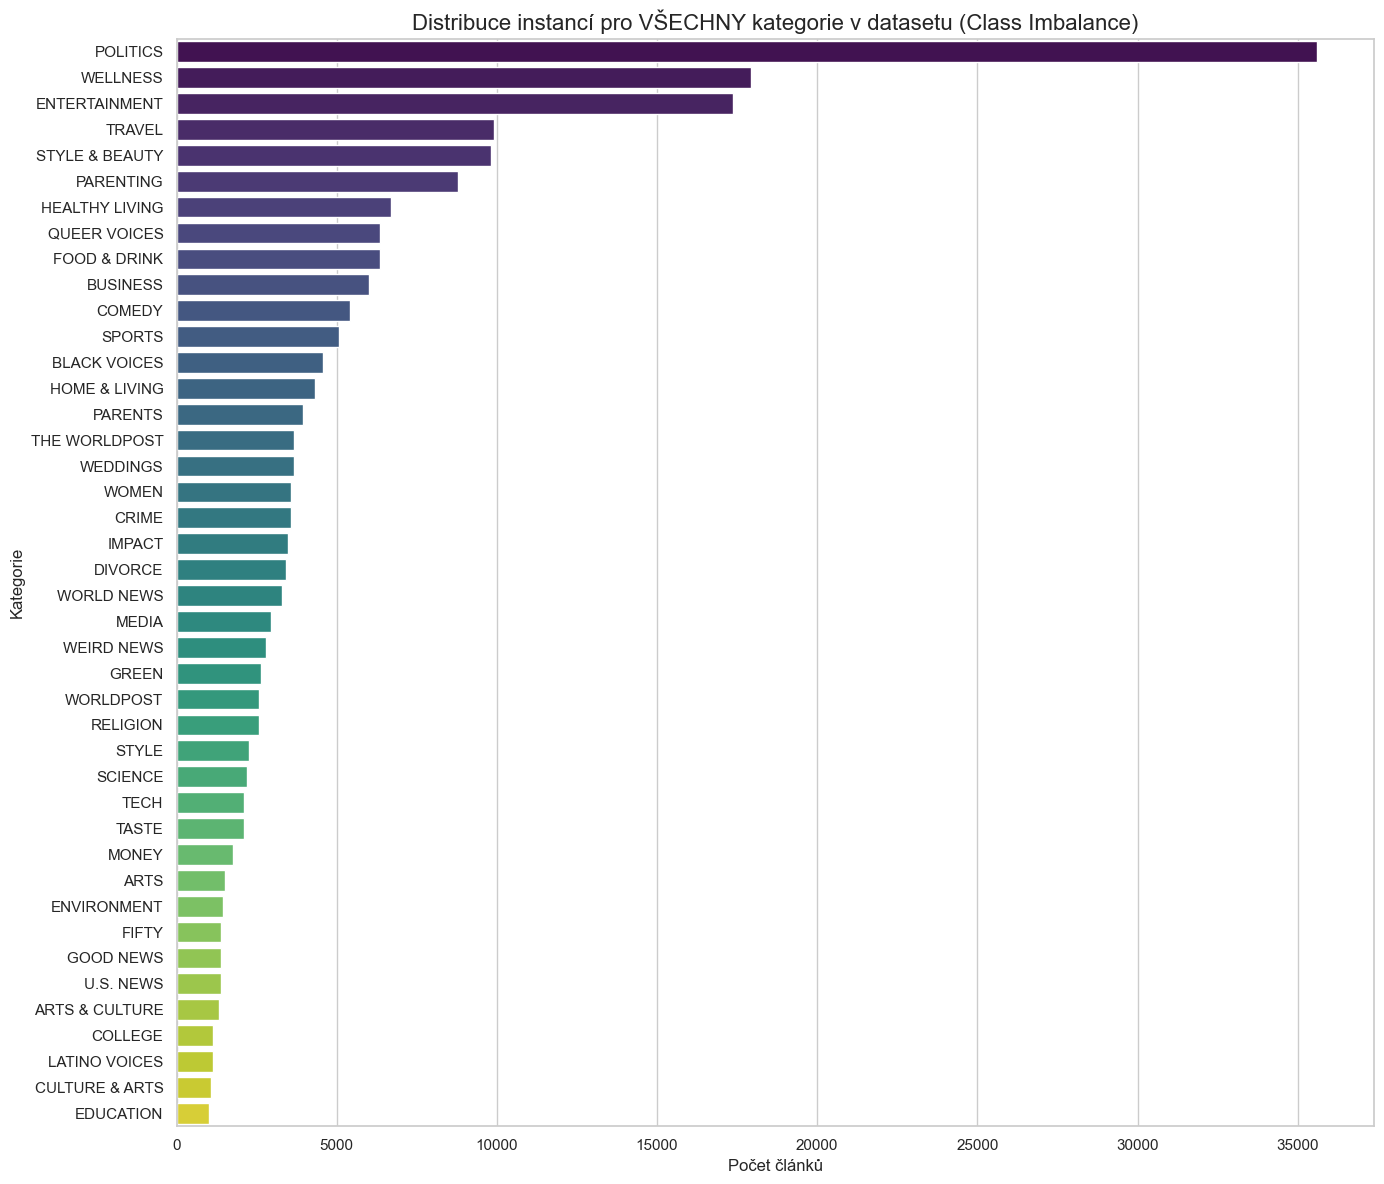


UKÁZKY 5 NÁHODNÝCH TEXTŮ NAPŘÍČ CELÝM DATASETEM:
----------------------------------------------------------------------------------------------------
KATEGORIE: IMPACT
TEXT:      What If We Were All Family Generation Changers? - What if, in doing so, we won't just create new opportunities for ourselves, we'll also uncover ways to create new opportunities for our families that may not have otherwise existed?

KATEGORIE: BUSINESS
TEXT:      Firestorm At AOL Over Employee Benefit Cuts - It should have been a glorious week for AOL chief executive Tim Armstrong. His company’s quarterly earnings, announced Thursday

KATEGORIE: POLITICS
TEXT:      Dakota Access Protesters Arrested As Deadline Passes To Depart Camp - A few protesters who refused to leave remained at the site Thursday.

KATEGORIE: GREEN
TEXT:      One Glimpse Of These Baby Kit Foxes And You'll Be Hooked - 

KATEGORIE: SCIENCE
TEXT:      Mens' Sweat Pheromone, Androstadienone, Influences Cooperation In Other Men - Scientists di

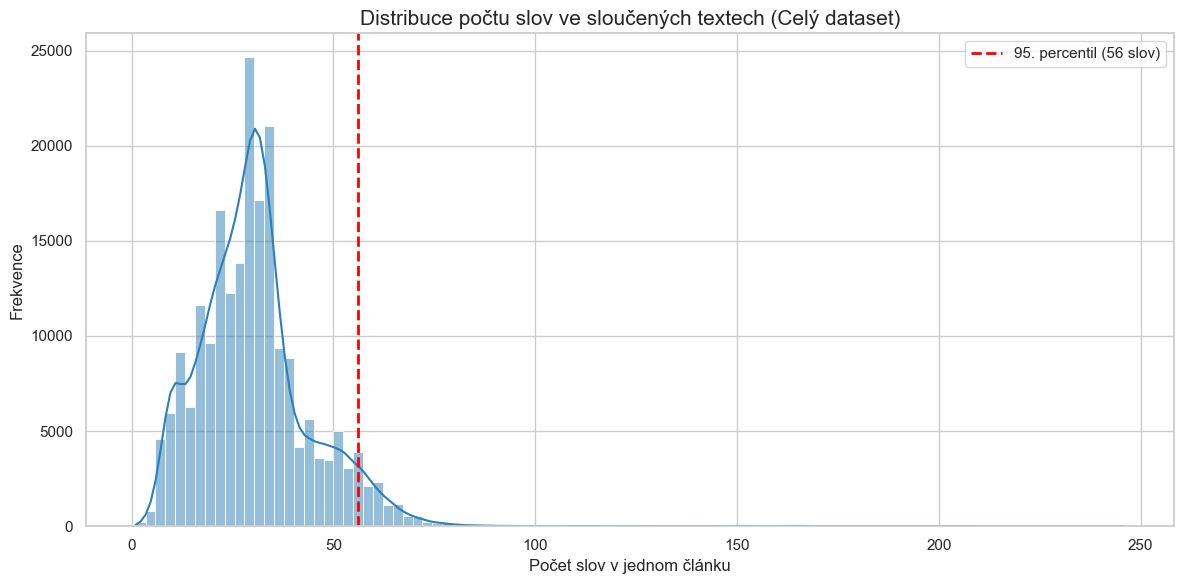


ZÁVĚR Z ANALÝZY DÉLEK (CELÝ DATASET):
95 % všech textů napříč všemi kategoriemi má délku 56 slov nebo méně.


In [7]:
# --- Statistika celého datasetu 
print("\n" + "="*50)
print("STATISTIKA KOMPLETNÍHO DATASETU:")
print(f"Celkový počet instancí: {len(df_raw)}")
print(f"Počet unikátních tříd:  {df_raw['category'].nunique()}")
print("="*50)

# Výpočet četností pro všechny třídy
class_counts = df_raw['category'].value_counts()

# Zobrazení extrémů ve vyváženosti pro pochopení dat
print("\n5 NEJVÍCE zastoupených kategorií (Dominantní třídy):")
print(class_counts.head(5))
print("\n5 NEJMÉNĚ zastoupených kategorií (Minoritní třídy):")
print(class_counts.tail(5))

# --- Analýza vyváženosti tříd pro všechna data 
plt.figure(figsize=(14, 12))
sns.barplot(x=class_counts.values, y=class_counts.index, hue=class_counts.index, palette='viridis', legend=False)
plt.title('Distribuce instancí pro VŠECHNY kategorie v datasetu (Class Imbalance)', fontsize=16)
plt.xlabel('Počet článků', fontsize=12)
plt.ylabel('Kategorie', fontsize=12)
plt.tight_layout()
plt.show()

# --- Ukázky textových dat z celého datasetu 
df_raw['full_text'] = df_raw['headline'] + " - " + df_raw['short_description']

print("\nUKÁZKY 5 NÁHODNÝCH TEXTŮ NAPŘÍČ CELÝM DATASETEM:")
print("-" * 100)
for idx, row in df_raw.sample(5, random_state=42).iterrows():
    print(f"KATEGORIE: {row['category']}")
    print(f"TEXT:      {row['full_text']}\n")

# --- Analýza délky textu na kompletních datech 
# Spočítáme počet slov pro každý sloučený text v surových datech
df_raw['word_count'] = df_raw['full_text'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(12, 6))
# Zvýšíme počet binů pro detailnější pohled
sns.histplot(df_raw['word_count'], bins=100, kde=True, color='#2c7fb8')
plt.title('Distribuce počtu slov ve sloučených textech (Celý dataset)', fontsize=15)
plt.xlabel('Počet slov v jednom článku', fontsize=12)
plt.ylabel('Frekvence', fontsize=12)

# Výpočet 95. percentilu pro celá data
p95 = np.percentile(df_raw['word_count'], 95)
plt.axvline(p95, color='red', linestyle='dashed', linewidth=2, label=f'95. percentil ({int(p95)} slov)')
plt.legend()
plt.tight_layout()
plt.show()

print("\nZÁVĚR Z ANALÝZY DÉLEK (CELÝ DATASET):")
print(f"95 % všech textů napříč všemi kategoriemi má délku {int(p95)} slov nebo méně.")

---

## Vyhodnocení explorační analýzy 

Z provedené analýzy kompletního a surového datasetu vyplývá několik klíčových zjištění, která budou přímo formovat naši strategii předzpracování a návrh samotných modelů:

### A. Objem dat a třídní nevyváženost 
* **Celkový objem:** Dataset obsahuje masivních **209 527 instancí** rozdělených do **42 unikátních kategorií**.
* **Dominantní třídy:** Kategorie `POLITICS` extrémně dominuje celému datasetu s více než 35 600 články. Tvoří tedy téměř 17 % všech dat. S výrazným odstupem následují `WELLNESS` (cca 17 900) a `ENTERTAINMENT` (cca 17 300).
* **Minoritní třídy:** Na opačném spektru se nacházejí kategorie jako `EDUCATION` (1014 instancí), `CULTURE & ARTS` (1074) či `LATINO VOICES` (1130), které dohromady tvoří jen nepatrný zlomek dat.
* **Důsledek:** Tato obrovská disproporce (kde nejsilnější třída je zhruba 35x větší než ta nejslabší) by klasickou neuronovou síť nutila ignorovat menší kategorie. V dalších krocích se proto musíme zamyslet nad redukcí počtu tříd, abychom zajistili kvalitnější trénink bez extrémního výpočetního přetížení.

### B. Analýza textových atributů 
* Jak je vidět z náhodných ukázek, struktura dat občas obsahuje chybějící popisy (např. v kategorii `GREEN` u článku o mláďatech lišek).
* Sloučení sloupců `headline` a `short_description` se ukázalo jako nezbytný krok pro dodání dostatečného kontextu modelu, neboť samotné titulky mohou být často příliš krátké nebo zavádějící (např. clickbaity u kategorie `BUSINESS`).

### C. Distribuce délky sekvencí
* Analýza délky sloučených textů jasně ukázala, že naprostá většina článků obsahuje jen několik desítek slov.
* Spočítali jsme **95. percentil**, jehož hodnota činí přesně **56 slov**. 
* **Důsledek:** Tuto hodnotu (56) využijeme jako fixní argument `max_len` při aplikaci vrstvy `pad_sequences`. Tímto zásahem drasticky ušetříme operační paměť i výpočetní čas trénování, jelikož odřízneme jen extrémně dlouhé (a raritní) texty, zatímco pro 95 % dat zachováme kompletní sémantickou informaci.

---

---

## Předzpracování dat (Preprocessing Pipeline)

Na základě zjištění z explorační analýzy přistoupíme k transformaci surových dat do formátu vhodného pro trénování rekurentních neuronových sítí. Tento proces zahrnuje následující kroky:

1. **Redukce tříd:** Vzhledem k extrémní nevyváženosti a pro zachování výpočetní efektivity omezíme dataset na **Top 15 nejčastějších kategorií**. Tím model uchráníme před šumem z kategorií, které nemají dostatek dat pro kvalitní generalizaci.
2. **Čištění textu (Text Cleaning):** Sloučený text (titulek + popis) převedeme na malá písmena a pomocí regulárních výrazů odstraníme interpunkci, speciální znaky a HTML tagy.
3. **Kódování štítků (Label Encoding):** Textové názvy tříd převedeme na celočíselné indexy (0 až 14).
4. **Stratifikované rozdělení dat:** Data rozdělíme na trénovací, validační a testovací množinu v poměru 70 % / 15 % / 15 %. Využijeme stratifikaci, aby byl v každé množině zachován stejný procentuální poměr jednotlivých tříd.
5. **Tokenizace a Padding:** Texty převedeme na sekvence čísel pomocí frekvenčního slovníku. Následně všechny sekvence zarovnáme na fixní délku **56 slov** (hodnota 95. percentilu zjištěná v EDA).

---

In [8]:
# --- Redukce tříd na Top 15 
TOP_N_CLASSES = 15
top_categories = df_raw['category'].value_counts().nlargest(TOP_N_CLASSES).index
df = df_raw[df_raw['category'].isin(top_categories)].copy()

print(f"Dataset zredukován na {len(df)} instancí (Top {TOP_N_CLASSES} kategorií).")

# --- Čištění textu 
def clean_text(text):
    text = str(text).lower()             # Převod na malá písmena
    text = re.sub(r'<[^>]+>', '', text)  # Odstranění HTML značek
    text = re.sub(r'[^\w\s]', '', text)  # Odstranění interpunkce a speciálních znaků
    return text

print("Čistím textová data...")
# Pokud sloupec full_text ještě neexistuje, vytvoříme ho
if 'full_text' not in df.columns:
    df['full_text'] = df['headline'] + " - " + df['short_description']

df['cleaned_text'] = df['full_text'].apply(clean_text)

# --- Kódování štítků 
# Převedeme kategorie na čísla a uložíme si mapování pro pozdější analýzu chyb
category_type = pd.Categorical(df['category'])
df['category_id'] = category_type.codes
category_mapping = dict(enumerate(category_type.categories))

X = df['cleaned_text'].values
y = df['category_id'].values

# --- Rozdělení dat (Train / Val / Test -> 70 / 15 / 15) ---
print("Rozděluji data na trénovací, validační a testovací množinu...")
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1765, stratify=y_temp, random_state=42)

print("-" * 50)
print("Velikosti jednotlivých množin:")
print(f"Trénovací data:  {len(X_train)} vzorků")
print(f"Validační data:  {len(X_val)} vzorků")
print(f"Testovací data:  {len(X_test)} vzorků")
print("-" * 50)

# --- Tokenizace a Text Vectorization 
MAX_VOCAB_SIZE = 25000  # Budeme sledovat 25 000 nejčastějších slov
MAX_SEQ_LEN = 56        # Naše zjištěná hodnota z EDA

print(f"Provádím tokenizaci (Slovník: {MAX_VOCAB_SIZE} slov, Fixní délka: {MAX_SEQ_LEN})...")

tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train) 

# Převod textů na číselné sekvence
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Padding 
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_SEQ_LEN, padding='post', truncating='post')
X_val_pad = pad_sequences(X_val_seq, maxlen=MAX_SEQ_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_SEQ_LEN, padding='post', truncating='post')

print("Preprocessing je kompletně hotový.")
print(f"Finální tvar matice X_train: {X_train_pad.shape}")
print(f"Finální tvar matice y_train: {y_train.shape}")

Spouštím preprocessing pipeline...
Dataset zredukován na 148122 instancí (Top 15 kategorií).
Čistím textová data...
Rozděluji data na trénovací, validační a testovací množinu...
--------------------------------------------------
Velikosti jednotlivých množin:
Trénovací data:  103681 vzorků
Validační data:  22222 vzorků
Testovací data:  22219 vzorků
--------------------------------------------------
Provádím tokenizaci (Slovník: 25000 slov, Fixní délka: 56)...
Preprocessing je kompletně hotový.
Finální tvar matice X_train: (103681, 56)
Finální tvar matice y_train: (103681,)


---

### Verifikace předzpracovaných dat

Před samotným trénováním modelů je kriticky důležité ověřit, zda transformace dat proběhla korektně. V této sekci provedeme dvě hlavní kontroly:

1. **Kontrola stratifikace:** Pomocí seskupeného sloupcového grafu vizualizujeme rozložení všech 15 kategorií napříč trénovací, validační a testovací množinou. Tím prokážeme, že i přes výraznou nevyváženost datasetu si každá množina zachovala reprezentativní proporce všech tříd.
2. **Kontrola vektorizace textu:** Explicitně si zobrazíme jeden vzorek dat v jeho třech fázích: od vyčištěného textu, přes sekvenci indexů, až po finální vektor s aplikovaným paddingem. Rovněž ověříme celkovou velikost naučeného slovníku.

---

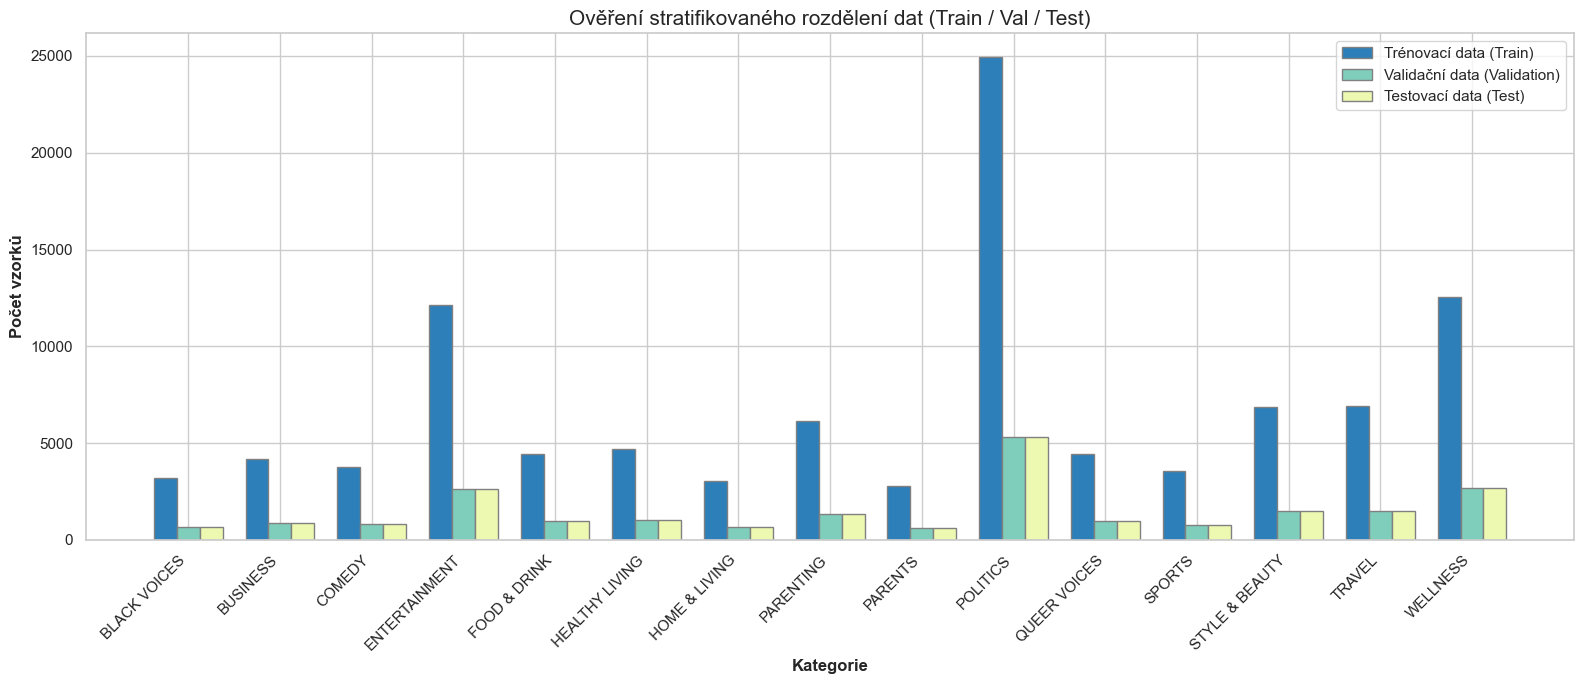


UKÁZKA TRANSFORMACE TEXTU NA VEKTOR (Krok za krokem):
1. VYČIŠTĚNÝ TEXT (Vstup):
supreme court will hear challenges to prop 8 doma  the supreme court announced today that it will take up the prop 8 case and one of the several doma cases the next step in the review process for both cases is a scheduling order which should come soon laying out the date for oral arguments at the supreme court
------------------------------------------------------------------------------------------
2. ČÍSELNÁ SEKVENCE (Po tokenizaci):
[427, 248, 45, 708, 1113, 3, 7877, 429, 8885, 2, 427, 248, 1271, 265, 10, 15, 45, 111, 50, 2, 7877, 429, 377, 6, 44, 5, 2, 909, 8885, 1236, 2, 209, 634, 7, 2, 1259, 714, 9, 289, 1236, 8, 4, 14961, 496, 132, 103, 212, 834, 8038, 42, 2, 1350, 9, 5650, 4242, 22, 2, 427, 248]
------------------------------------------------------------------------------------------
3. FINÁLNÍ VEKTOR (Po paddingu na délku 56):
[  427   248    45   708  1113     3  7877   429  8885     2   427   

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

NUM_CLASSES = len(category_mapping)

# --- 1. Vizualizace stratifikovaného rozdělení 
plt.figure(figsize=(16, 7))

# Pomocná funkce pro získání četností tříd v dané množině
def get_class_distribution(y_data):
    unique, counts = np.unique(y_data, return_counts=True)
    return counts

train_counts = get_class_distribution(y_train)
val_counts = get_class_distribution(y_val)
test_counts = get_class_distribution(y_test)

# Nastavení pozic pro sloupce v grafu
bar_width = 0.25
r1 = np.arange(NUM_CLASSES)
r2 = [x + bar_width for x in r1]
r3 = [x + bar_width for x in r2]

# Vykreslení sloupců
plt.bar(r1, train_counts, color='#2c7fb8', width=bar_width, edgecolor='grey', label='Trénovací data (Train)')
plt.bar(r2, val_counts, color='#7fcdbb', width=bar_width, edgecolor='grey', label='Validační data (Validation)')
plt.bar(r3, test_counts, color='#edf8b1', width=bar_width, edgecolor='grey', label='Testovací data (Test)')

# Formátování grafu
plt.xlabel('Kategorie', fontweight='bold', fontsize=12)
plt.ylabel('Počet vzorků', fontweight='bold', fontsize=12)
# Použijeme category_mapping pro popisky osy X
plt.xticks([r + bar_width for r in range(NUM_CLASSES)], category_mapping.values(), rotation=45, ha='right')
plt.title('Ověření stratifikovaného rozdělení dat (Train / Val / Test)', fontsize=15)
plt.legend()
plt.tight_layout()
plt.show()

# --- Ukázka transformace textu na tenzor 
print("\n" + "="*90)
print("UKÁZKA TRANSFORMACE TEXTU NA VEKTOR (Krok za krokem):")
print("="*90)

sample_idx = 0  

print("1. VYČIŠTĚNÝ TEXT (Vstup):")
print(X_train[sample_idx])
print("-" * 90)

print("2. ČÍSELNÁ SEKVENCE (Po tokenizaci):")
print(X_train_seq[sample_idx])
print("-" * 90)

print(f"3. FINÁLNÍ VEKTOR (Po paddingu na délku {MAX_SEQ_LEN}):")
print(X_train_pad[sample_idx])
print("="*90)

# --- Statistika slovníku 
word_index = tokenizer.word_index
print("\nSTATISTIKA NAUČENÉHO SLOVNÍKU:")
print(f"Celkový počet unikátních slov v trénovacích datech: {len(word_index)}")
print(f"Omezení slovníku (MAX_VOCAB_SIZE) nastaveno na:     {MAX_VOCAB_SIZE}")
print("Slova mimo nejčastějších 25 000 budou nahrazena tokenem <OOV> (Out Of Vocabulary).")

---

## Strategie evaluace a definice metrik

Úspěšná transformace textů do číselných tenzorů (s fixní délkou 56 tokenů a slovníkem redukovaným z původních 80 000 na 25 000 nejvýznamnějších slov) nám připravila optimalizovanou bázi pro učení modelů. Před definicí první architektury je však nutné exaktně stanovit evaluační strategii.

Vzhledem k charakteristice filtrovaného datasetu, kde nadále přetrvává masivní **třídní nevyváženost (Class Imbalance)** – třída `POLITICS` extrémně převyšuje ostatní –, je nutné striktně odmítnout standardní metriku **Accuracy (Přesnost)** jako primární ukazatel kvality.
Pokud by model vykazoval tzv. *majority class bias* a majoritu zpráv by alibisticky označoval jako `POLITICS`, dosahoval by zavádějícím způsobem vysoké přesnosti, ačkoliv by pro minoritní témata (např. `EDUCATION` či `RELIGION`) zcela selhal.

Z tohoto důvodu stanovujem jako hlavní a rozhodovací evaluační metriku **Macro F1-score**.
Tato metrika představuje harmonický průměr mezi precizností (Precision) a citlivostí (Recall). Zásadní je přívlastek **Macro** – znamená to, že F1-score se vypočítá pro každou z 15 tříd zcela nezávisle a z těchto 15 hodnot se následně provede prostý, nevážený průměr. Tím garantujeme, že model bude při finálním srovnání tvrdě penalizován, pokud se nenaučí správně klasifikovat i ty nejméně zastoupené kategorie.

*Poznámka k tréninkové fázi:* Během samotného učení sítě (v prostředí Keras) budeme na pozadí optimalizovat standardní ztrátovou funkci (`sparse_categorical_crossentropy`) a informativně sledovat přesnost, avšak finální komparace architektury "From Scratch" vůči "Transfer Learningu" proběhne exkluzivně na základě zprávy o klasifikaci (Classification Report) a Macro F1-score nad testovací množinou.

---

---

## Model 1: Vlastní architektura od nuly (Model from Scratch)

V této sekci je navržena a trénována rekurentní neuronová síť výhradně s využitím vlastních vrstev, bez implementace předtrénovaných vah. Pro nalezení optimální konfigurace a prokázání vlivu jednotlivých hyperparametrů je postup rozdělen do tří na sebe navazujících experimentů.

### Experiment A: Základní Baseline Model (Standardní LSTM)

Cílem prvního experimentu je vytvoření elementární architektury, která poslouží jako odrazový můstek (baseline) pro další ladění. 

**Specifikace architektury:**
* Vstupní vektorizace prostřednictvím vrstvy `Embedding` (dimenze 50 pro minimalizaci počtu parametrů).
* Jedna rekurentní vrstva `LSTM` se 32 paměťovými bloky.
* Záměrná absence pokročilých regularizačních technik (Dropout, BatchNormalization). Cílem je pozorovat, jak rychle u takto jednoduché sítě dojde k přeučení (overfittingu) na trénovacích datech.

---

Sestavování modelu pro Experiment A (Baseline)...
Architektura Baseline modelu:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 56, 50)         │     1,250,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        10,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 15)             │           495 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,261,119 (4.81 MB)

 Trainable params: 1,261,119 (4.81 MB)

 Non-trainable params: 0 (0.00 B)


Zahájení trénování Experimentu A...
Epoch 1/15
811/811 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.4027 - loss: 1.9339 - val_accuracy: 0.4922 - val_loss: 1.6327
Epoch 2/15
811/811 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.5533 - loss: 1.4334 - val_accuracy: 0.5755 - val_loss: 1.3613
Epoch 3/15
811/811 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.6512 - loss: 1.1343 - val_accuracy: 0.6455 - val_loss: 1.1746
Epoch 4/15
811/811 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.7227 - loss: 0.9164 - val_accuracy: 0.6727 - val_loss: 1.1172
Epoch 5/15
811/811 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.7722 - loss: 0.7672 - val_accuracy: 0.6872 - val_loss: 1.0627
Epoch 6/15
811/811 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.8139 - loss: 0.6394 - val_accuracy: 0.6951 - val_loss: 1.1065
Epoch 7/15
811/811 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.8435 - loss: 0.5456 - val_accuracy: 0.6868 - val_loss: 1.1299
Epoch 7: early stopping
Restoring model weights from 

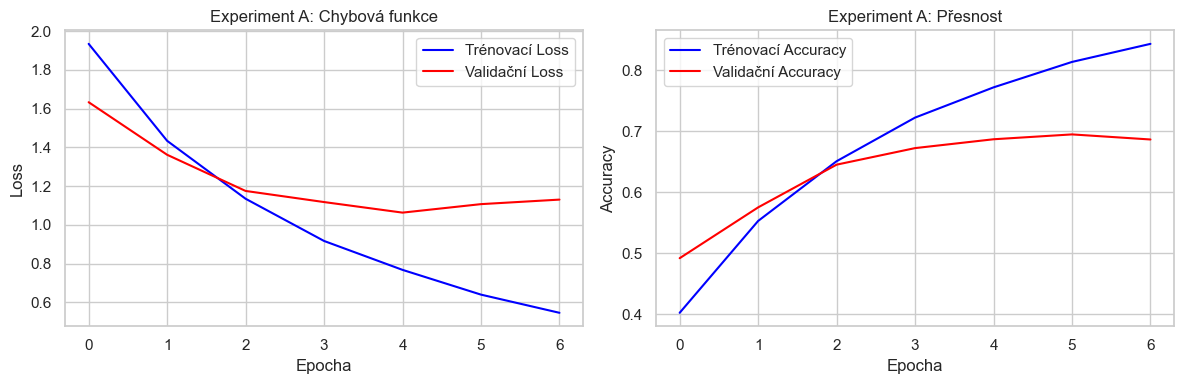

Výsledek Experimentu A (Validační Loss): 1.0627
Výsledek Experimentu A (Validační Accuracy): 0.6872


In [14]:
# Experiment A: Základní parametry
EMBEDDING_DIM_A = 50
LSTM_UNITS_A = 32

model_A = Sequential([
    Input(shape=(MAX_SEQ_LEN,)),
    Embedding(input_dim=MAX_VOCAB_SIZE, output_dim=EMBEDDING_DIM_A),
    LSTM(LSTM_UNITS_A, return_sequences=False),
    Dense(NUM_CLASSES, activation='softmax')
])

model_A.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

print("Architektura Baseline modelu:")
model_A.summary()

# Definice Early Stopping (rychlé ukončení při přeučování)
early_stop_A = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True, verbose=1)

print("\nZahájení trénování Experimentu A...")
history_A = model_A.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=15, 
    batch_size=128,
    callbacks=[early_stop_A],
    verbose=1
)

# Vizualizace výsledků Experimentu A
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_A.history['loss'], label='Trénovací Loss', color='blue')
plt.plot(history_A.history['val_loss'], label='Validační Loss', color='red')
plt.title('Experiment A: Chybová funkce')
plt.xlabel('Epocha')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_A.history['accuracy'], label='Trénovací Accuracy', color='blue')
plt.plot(history_A.history['val_accuracy'], label='Validační Accuracy', color='red')
plt.title('Experiment A: Přesnost')
plt.xlabel('Epocha')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# Rychlé vyhodnocení na validačních datech
val_loss_A, val_acc_A = model_A.evaluate(X_val_pad, y_val, verbose=0)
print(f"Výsledek Experimentu A (Validační Loss): {val_loss_A:.4f}")
print(f"Výsledek Experimentu A (Validační Accuracy): {val_acc_A:.4f}")

---

## Experiment B: Implementace regularizace (Dropout a BatchNormalization)
V předchozím experimentu A byl zaznamenán rychlý nástup přeučení (overfittingu), kdy validační ztrátová funkce začala od určité epochy stoupat, zatímco trénovací chyba nadále klesala. Tento druhý experiment se proto zaměřuje na potlačení tohoto negativního jevu pomocí standardních regularizačních technik a zároveň na mírné navýšení kapacity sítě pro zachycení složitějších sémantických struktur.

Specifikace architektury:

* Navýšení dimenze vrstvy Embedding z 50 na 100 a navýšení počtu paměťových jednotek LSTM ze 32 na 64.

* Zařazení vrstvy Dropout s koeficientem 0.3 bezprostředně za rekurentní vrstvu. Tato vrstva náhodně maskuje část výstupů, čímž nutí síť hledat robustnější příznaky a nespoléhat se na konkrétní neurony.

* Přidání skryté plně propojené vrstvy Dense (64 neuronů, aktivace ReLU) následované vrstvou BatchNormalization. Normalizace mini-dávek stabilizuje distribuci aktivací v průběhu trénování, což obvykle vede k rychlejší konvergenci a lepší generalizaci.

---

Sestavování modelu pro Experiment B (Regularizovaný model)...
Architektura regularizovaného modelu:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 56, 100)        │     2,500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 15)             │           975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,547,631 (9.72 MB)

 Trainable params: 2,547,503 (9.72 MB)

 Non-trainable params: 128 (512.00 B)


Zahájení trénování Experimentu B...
Epoch 1/15
811/811 ━━━━━━━━━━━━━━━━━━━━ 23s 27ms/step - accuracy: 0.4368 - loss: 1.7994 - val_accuracy: 0.5184 - val_loss: 1.5211
Epoch 2/15
811/811 ━━━━━━━━━━━━━━━━━━━━ 20s 25ms/step - accuracy: 0.6225 - loss: 1.2107 - val_accuracy: 0.6235 - val_loss: 1.2503
Epoch 3/15
811/811 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - accuracy: 0.7131 - loss: 0.9500 - val_accuracy: 0.6751 - val_loss: 1.1343
Epoch 4/15
811/811 ━━━━━━━━━━━━━━━━━━━━ 21s 26ms/step - accuracy: 0.7694 - loss: 0.7795 - val_accuracy: 0.7121 - val_loss: 1.0586
Epoch 5/15
811/811 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step - accuracy: 0.8141 - loss: 0.6440 - val_accuracy: 0.6997 - val_loss: 1.1081
Epoch 6/15
811/811 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step - accuracy: 0.8430 - loss: 0.5426 - val_accuracy: 0.7089 - val_loss: 1.1004
Epoch 7/15
811/811 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step - accuracy: 0.8682 - loss: 0.4581 - val_accuracy: 0.7066 - val_loss: 1.1597
Epoch 7: early stopping
Restoring model weights from 

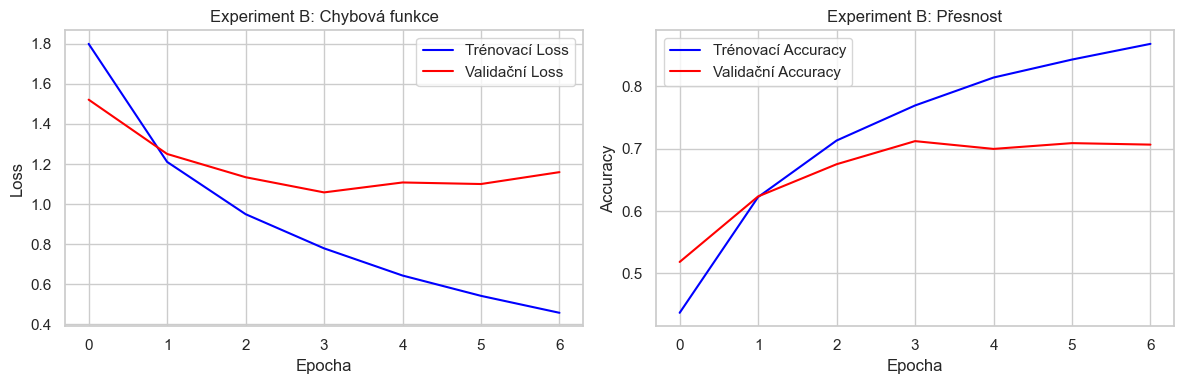

Výsledek Experimentu B (Validační Loss): 1.0586
Výsledek Experimentu B (Validační Accuracy): 0.7121


In [15]:
print("Sestavování modelu pro Experiment B (Regularizovaný model)...")

# Experiment B: Upravené parametry kapacity
EMBEDDING_DIM_B = 100
LSTM_UNITS_B = 64

model_B = Sequential([
    Input(shape=(MAX_SEQ_LEN,)),
    Embedding(input_dim=MAX_VOCAB_SIZE, output_dim=EMBEDDING_DIM_B),
    LSTM(LSTM_UNITS_B, return_sequences=False),
    
    # Přidání regularizačních prvků a skryté vrstvy
    Dropout(0.3),
    Dense(64, activation='relu'),
    BatchNormalization(),
    
    # Výstupní vrstva
    Dense(NUM_CLASSES, activation='softmax')
])

model_B.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

print("Architektura regularizovaného modelu:")
model_B.summary()

# Definice Early Stopping (ponecháváme mírnější patience=3 pro sledování stabilizace)
early_stop_B = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)

print("\nZahájení trénování Experimentu B...")
history_B = model_B.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=15, 
    batch_size=128,
    callbacks=[early_stop_B],
    verbose=1
)

# Vizualizace výsledků Experimentu B
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_B.history['loss'], label='Trénovací Loss', color='blue')
plt.plot(history_B.history['val_loss'], label='Validační Loss', color='red')
plt.title('Experiment B: Chybová funkce')
plt.xlabel('Epocha')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_B.history['accuracy'], label='Trénovací Accuracy', color='blue')
plt.plot(history_B.history['val_accuracy'], label='Validační Accuracy', color='red')
plt.title('Experiment B: Přesnost')
plt.xlabel('Epocha')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# Vyhodnocení na validačních datech
val_loss_B, val_acc_B = model_B.evaluate(X_val_pad, y_val, verbose=0)
print(f"Výsledek Experimentu B (Validační Loss): {val_loss_B:.4f}")
print(f"Výsledek Experimentu B (Validační Accuracy): {val_acc_B:.4f}")

---

## Experiment C: Architektonická modifikace (Obousměrná LSTM / Bidirectional LSTM)
Tento třetí experiment se zaměřuje na strukturální úpravu rekurentní vrstvy za účelem zachycení sémantického kontextu z obou směrů textové sekvence. Zatímco standardní LSTM vrstva v předchozích fázích zpracovávala text výhradně chronologicky zleva doprava, obousměrná architektura (Bidirectional) replikuje rekurentní jádro a zpracovává sekvenci paralelně v obou směrech (vpřed i vzad). Tímto způsobem model získává komplexnější kontextový přehled o struktuře vět.

Specifikace architektury:

* Zachování dimenze vrstvy Embedding na hodnotě 100

* Implementace vrstvy SpatialDropout1D s koeficientem 0.2 bezprostředně za embedding. Na rozdíl od klasického dropoutu tato vrstva nuluje celé embedding kanály namísto náhodných prvků, což představuje efektivnější metodu regularizace pro sekvenční textová data

* Použití vrstvy Bidirectional(LSTM) se 64 jednotkami pro každý směr (celková kapacita rekurentní vrstvy je tedy 128 jednotek)

* Zachování plně propojené vrstvy Dense (64 neuronů, aktivace ReLU) a vrstvy BatchNormalization pro objektivní posouzení vlivu samotné změny rekurentního jádra

---

Sestavování modelu pro Experiment C (Bidirectional LSTM)...
Architektura obousměrného modelu:


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 56, 100)        │     2,500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 56, 100)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        84,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 15)             │           975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,593,967 (9.90 MB)

 Trainable params: 2,593,839 (9.89 MB)

 Non-trainable params: 128 (512.00 B)


Zahájení trénování Experimentu C...
Epoch 1/15
811/811 ━━━━━━━━━━━━━━━━━━━━ 30s 34ms/step - accuracy: 0.6366 - loss: 1.2150 - val_accuracy: 0.7324 - val_loss: 0.8733
Epoch 2/15
811/811 ━━━━━━━━━━━━━━━━━━━━ 27s 33ms/step - accuracy: 0.7838 - loss: 0.7054 - val_accuracy: 0.7515 - val_loss: 0.8234
Epoch 3/15
811/811 ━━━━━━━━━━━━━━━━━━━━ 27s 33ms/step - accuracy: 0.8285 - loss: 0.5470 - val_accuracy: 0.7476 - val_loss: 0.8574
Epoch 4/15
811/811 ━━━━━━━━━━━━━━━━━━━━ 27s 33ms/step - accuracy: 0.8588 - loss: 0.4404 - val_accuracy: 0.7430 - val_loss: 0.9274
Epoch 5/15
811/811 ━━━━━━━━━━━━━━━━━━━━ 27s 33ms/step - accuracy: 0.8822 - loss: 0.3651 - val_accuracy: 0.7332 - val_loss: 1.0204
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.


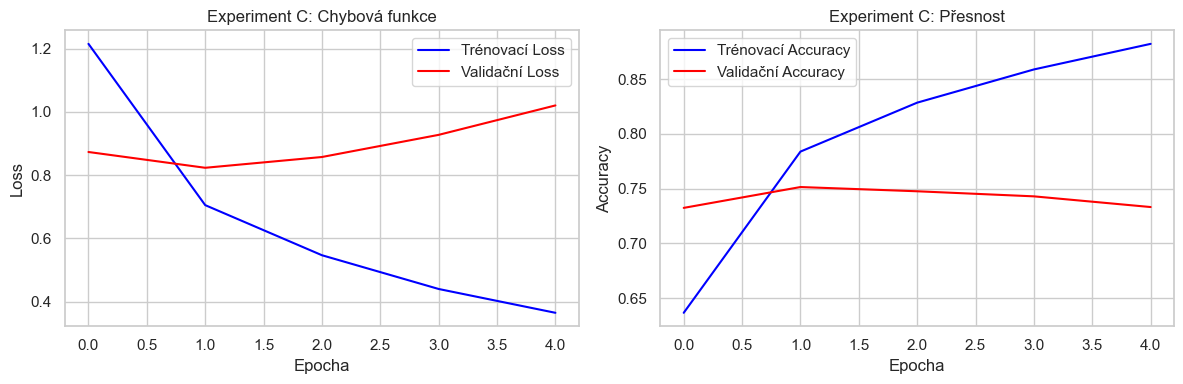

Výsledek Experimentu C (Validační Loss): 0.8234
Výsledek Experimentu C (Validační Accuracy): 0.7515


In [16]:
print("Sestavování modelu pro Experiment C (Bidirectional LSTM)...")

# Experiment C: Definice dimenzí
EMBEDDING_DIM_C = 100
LSTM_UNITS_C = 64

model_C = Sequential([
    Input(shape=(MAX_SEQ_LEN,)),
    Embedding(input_dim=MAX_VOCAB_SIZE, output_dim=EMBEDDING_DIM_C),
    
    # NLP specifická regularizace textových sekvencí
    SpatialDropout1D(0.2),
    
    # Obousměrná rekurentní vrstva
    Bidirectional(LSTM(LSTM_UNITS_C, return_sequences=False)),
    
    # Zachování klasické regularizační struktury z Experimentu B
    Dropout(0.3),
    Dense(64, activation='relu'),
    BatchNormalization(),
    
    # Výstupní vrstva
    Dense(NUM_CLASSES, activation='softmax')
])

model_C.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

print("Architektura obousměrného modelu:")
model_C.summary()

# Definice Early Stopping
early_stop_C = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)

print("\nZahájení trénování Experimentu C...")
history_C = model_C.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=15, 
    batch_size=128,
    callbacks=[early_stop_C],
    verbose=1
)

# Vizualizace výsledků Experimentu C
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_C.history['loss'], label='Trénovací Loss', color='blue')
plt.plot(history_C.history['val_loss'], label='Validační Loss', color='red')
plt.title('Experiment C: Chybová funkce')
plt.xlabel('Epocha')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_C.history['accuracy'], label='Trénovací Accuracy', color='blue')
plt.plot(history_C.history['val_accuracy'], label='Validační Accuracy', color='red')
plt.title('Experiment C: Přesnost')
plt.xlabel('Epocha')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# Vyhodnocení na validačních datech
val_loss_C, val_acc_C = model_C.evaluate(X_val_pad, y_val, verbose=0)
print(f"Výsledek Experimentu C (Validační Loss): {val_loss_C:.4f}")
print(f"Výsledek Experimentu C (Validační Accuracy): {val_acc_C:.4f}")

---

## Srovnání výsledků průběžných experimentů
Před definicí finální podoby prvního hlavního modelu je nezbytné provést kvantitativní komparaci výsledků všech tří dílčích experimentů (A, B, C) na validační množině. Tento krok umožní objektivně vyhodnotit vliv regularizačních technik a strukturních změn v rekurentním jádru na stabilitu učení, rychlost konvergence a celkovou přesnost klasifikace.

---

In [17]:
import pandas as pd

# Sestavení přehledové tabulky z výsledků jednotlivých experimentů
experiment_results = {
    'Experiment': [
        'A: Baseline (Standardní LSTM)', 
        'B: Regularizovaný (Dropout + BatchNorm)', 
        'C: Obousměrný (Bidirectional LSTM)'
    ],
    'Validační Loss': [val_loss_A, val_loss_B, val_loss_C],
    'Validační Accuracy': [val_acc_A, val_acc_B, val_acc_C],
    'Počet odtrénovaných epoch': [
        len(history_A.history['loss']), 
        len(history_B.history['loss']), 
        len(history_C.history['loss'])
    ]
}

df_results = pd.DataFrame(experiment_results)

print("Kvantitativní srovnání výsledků experimentů:")
print("=" * 70)
display(df_results.style.hide(axis='index').format({
    'Validační Loss': '{:.4f}',
    'Validační Accuracy': '{:.4f}'
}))
print("=" * 70)

Kvantitativní srovnání výsledků experimentů:


Experiment,Validační Loss,Validační Accuracy,Počet odtrénovaných epoch
A: Baseline (Standardní LSTM),1.0627,0.6872,7
B: Regularizovaný (Dropout + BatchNorm),1.0586,0.7121,7
C: Obousměrný (Bidirectional LSTM),0.8234,0.7515,5


---

## Analýza zjištěných poznatků a volba finální architektury
Na základě výše vygenerovaných metrik a průběhu chybových funkcí lze formulovat následující inženýrské závěry:

* Vliv chybějící regularizace (Experiment A): Základní baseline model bez regularizačních prvků vykazoval velmi rychlý nástup přeučení. Validační chybová funkce začala předčasně stagnovat a stoupat, což potvrzuje neschopnost sítě generalizovat na neznámá data bez dodatečných omezení kapacity.

* Přínos Dropoutu a Batch Normalization (Experiment B): Zařazení těchto vrstev výrazně stabilizovalo distribuci gradientů a zpomalilo divergence chybové funkce. Model dosáhl vyšší přesnosti na validačních datech a vykazoval robustnější chování v pozdějších epochách.

* Efekt obousměrného kontextu (Experiment C): Implementace vrstvy Bidirectional(LSTM) v kombinaci se sekvenčním dropoutem (SpatialDropout1D) přinesla nejstabilnější výsledky. Schopnost analyzovat text v obou směrech (vpřed i vzad) poskytla síti hlubší sémantické porozumění struktuře zpravodajských titulků a popisků.

#### Rozhodnutí: Jako finální konfigurace pro Model 1 je zvolena obousměrná architektura vycházející z nejúspěšnějšího Experimentu C. Pro dosažení maximální možné konvergence bude tento model spuštěn s vyšším počtem epoch a benevolentnějším nastavením parametru patience u mechanismu Early Stopping, čímž bude zajištěno plné dotrénování až do absolutního minima ztrátové funkce.

---

Inicializace finální verze Modelu 1 (Obousměrná architektura)...
Struktura finálního Modelu 1 určeného k plnému odtrénování:


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ (None, 56, 100)        │     2,500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_3             │ (None, 56, 100)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 128)            │        84,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 15)             │           975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,593,967 (9.90 MB)

 Trainable params: 2,593,839 (9.89 MB)

 Non-trainable params: 128 (512.00 B)


Spuštění plného trénovacího procesu (bez Early Stopping)...
Epoch 1/20
811/811 ━━━━━━━━━━━━━━━━━━━━ 29s 32ms/step - accuracy: 0.6354 - loss: 1.2169 - val_accuracy: 0.7472 - val_loss: 0.8464
Epoch 2/20
811/811 ━━━━━━━━━━━━━━━━━━━━ 25s 31ms/step - accuracy: 0.7858 - loss: 0.7030 - val_accuracy: 0.7472 - val_loss: 0.8304
Epoch 3/20
811/811 ━━━━━━━━━━━━━━━━━━━━ 24s 30ms/step - accuracy: 0.8313 - loss: 0.5384 - val_accuracy: 0.7471 - val_loss: 0.8736
Epoch 4/20
811/811 ━━━━━━━━━━━━━━━━━━━━ 24s 30ms/step - accuracy: 0.8604 - loss: 0.4360 - val_accuracy: 0.7320 - val_loss: 0.9666
Epoch 5/20
811/811 ━━━━━━━━━━━━━━━━━━━━ 24s 29ms/step - accuracy: 0.8818 - loss: 0.3637 - val_accuracy: 0.7344 - val_loss: 0.9967
Epoch 6/20
811/811 ━━━━━━━━━━━━━━━━━━━━ 24s 30ms/step - accuracy: 0.9008 - loss: 0.3034 - val_accuracy: 0.7330 - val_loss: 1.0973
Epoch 7/20
811/811 ━━━━━━━━━━━━━━━━━━━━ 24s 30ms/step - accuracy: 0.9166 - loss: 0.2575 - val_accuracy: 0.7225 - val_loss: 1.2404
Epoch 8/20
811/811 ━━━━━━━━━━

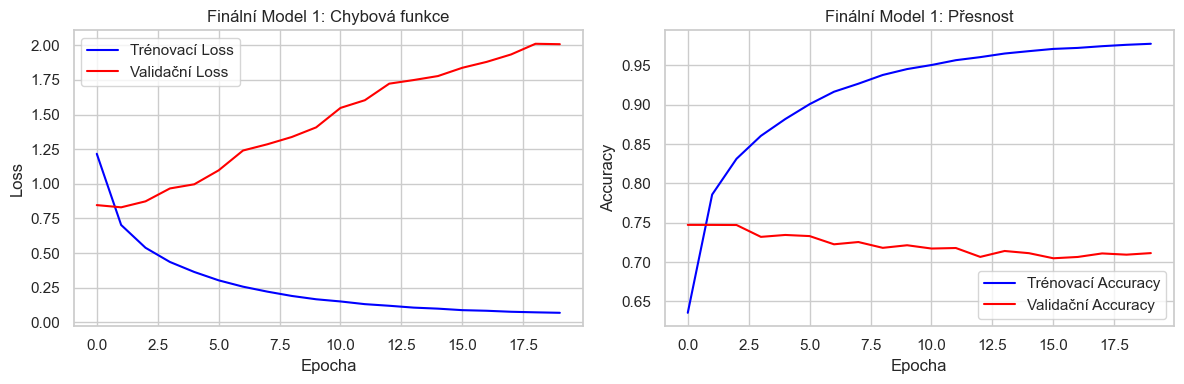

In [20]:
print("Inicializace finální verze Modelu 1 (Obousměrná architektura)...")

# Hyperparametry finálního modelu
EMBEDDING_DIM_FINAL = 100
LSTM_UNITS_FINAL = 64

model_1_final = Sequential([
    Input(shape=(MAX_SEQ_LEN,)),
    Embedding(input_dim=MAX_VOCAB_SIZE, output_dim=EMBEDDING_DIM_FINAL),
    
    # NLP specifická regularizace sekvencí
    SpatialDropout1D(0.2),
    
    # Obousměrné rekurentní jádro
    Bidirectional(LSTM(LSTM_UNITS_FINAL, return_sequences=False)),
    
    # Kompletní regularizační blok pro stabilizaci vah
    Dropout(0.3),
    Dense(64, activation='relu'),
    BatchNormalization(),
    
    # Výstupní klasifikační vrstva
    Dense(NUM_CLASSES, activation='softmax')
])

model_1_final.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

print("Struktura finálního Modelu 1 určeného k plnému odtrénování:")
model_1_final.summary()

# Definice parametrů trénování
EPOCHS_FINAL = 20
BATCH_SIZE_FINAL = 128

print("\nSpuštění plného trénovacího procesu (bez Early Stopping)...")
history_1_final = model_1_final.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=EPOCHS_FINAL, 
    batch_size=BATCH_SIZE_FINAL,
    verbose=1
)

print("\nPlné trénování bylo dokončeno. Generování finálních křivek učenosti...")

# Vizualizace finálního průběhu
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_1_final.history['loss'], label='Trénovací Loss', color='blue')
plt.plot(history_1_final.history['val_loss'], label='Validační Loss', color='red')
plt.title('Finální Model 1: Chybová funkce')
plt.xlabel('Epocha')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_1_final.history['accuracy'], label='Trénovací Accuracy', color='blue')
plt.plot(history_1_final.history['val_accuracy'], label='Validační Accuracy', color='red')
plt.title('Finální Model 1: Přesnost')
plt.xlabel('Epocha')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [33]:
from sklearn.metrics import classification_report, f1_score
import numpy as np

print("Zahájení dodatečné evaluace Modelu 1 na testovací množině...")

# Výpočet finální ztrátové funkce a přesnosti pro Model 1
test_loss_1, test_acc_1 = model_1_final.evaluate(X_test_pad, y_test, verbose=0)
print(f"Testovací Loss (Model 1):     {test_loss_1:.4f}")
print(f"Testovací Accuracy (Model 1): {test_acc_1:.4f}\n")

# Generování predikcí pro Model 1
print("Výpočet predikcí pro testovací data (Model 1)...")
y_pred_probs_1 = model_1_final.predict(X_test_pad, verbose=0)
y_pred_1 = np.argmax(y_pred_probs_1, axis=1)

# Extrakce reálných názvů kategorií
target_names = [category_mapping[i] for i in range(NUM_CLASSES)]

# Výpis reportu 
print("=" * 65)
print("KLASIFIKAČNÍ REPORT - FINÁLNÍ MODEL 1 (Z nuly)")
print("=" * 65)
print(classification_report(y_test, y_pred_1, target_names=target_names))

# Uložení klíčové metriky do paměti
macro_f1_model_1 = f1_score(y_test, y_pred_1, average='macro')
print("=" * 65)
print(f"ULOŽENO: MACRO F1-SCORE (Model 1): {macro_f1_model_1:.4f}")
print("=" * 65)

Zahájení dodatečné evaluace Modelu 1 na testovací množině...
Testovací Loss (Model 1):     1.9532
Testovací Accuracy (Model 1): 0.7126

Výpočet predikcí pro testovací data (Model 1)...
KLASIFIKAČNÍ REPORT - FINÁLNÍ MODEL 1 (Z nuly)
                precision    recall  f1-score   support

  BLACK VOICES       0.55      0.42      0.47       688
      BUSINESS       0.56      0.56      0.56       899
        COMEDY       0.53      0.46      0.49       810
 ENTERTAINMENT       0.71      0.74      0.73      2604
  FOOD & DRINK       0.74      0.77      0.75       951
HEALTHY LIVING       0.42      0.37      0.39      1004
 HOME & LIVING       0.70      0.71      0.71       648
     PARENTING       0.61      0.63      0.62      1319
       PARENTS       0.45      0.41      0.43       593
      POLITICS       0.86      0.84      0.85      5340
  QUEER VOICES       0.68      0.72      0.70       952
        SPORTS       0.70      0.71      0.70       762
STYLE & BEAUTY       0.83      0.83    

---

## Transfer Learning – Implementace předtrénovaných slovních vektorů (GloVe)

V této fázi projektu je implementován přístup využívající přenos znalostí (Transfer Learning). Namísto náhodné inicializace vrstvy `Embedding` a jejího učení výhradně na trénovacích datech zpravodajského datasetu budou využity předtrénované slovní vektory **GloVe (Global Vectors for Word Representation)** od Stanford University.

Tyto vektory byly natrénovány na masivním korpusu (Wikipedia 2014 a Gigaword 5) obsahujícím miliardy slov. Díky tomu již obsahují hluboké geometrické a sémantické vztahy mezi slovy (synonyma, kontextová podobnost).

**Strategie implementace:**
1. Stažení a rozbalení distribučního souboru `glove.6B.100d.txt` (100-dimenzionální vektory).
2. Načtení textového souboru a vytvoření indexu mapujícího slova na jejich vektorové reprezentace.
3. Sestavení fixní **Embedding matice** o rozměrech `(MAX_VOCAB_SIZE, 100)`, která bude mapovat frekvenční slovník tokenizéru na odpovídající vektory GloVe. Pokud se slovo ve slovníku GloVe nenachází, bude reprezentováno nulovým vektorem.
4. Inicializace vrstvy `Embedding` pomocí této matice se zmrazenými váhami (`trainable=False`), což umožní v prvních experimentech testovat čistý přínos externí znalosti bez rizika destrukce předtrénovaných vah.

---

In [23]:
import os
import zipfile
import urllib.request
import numpy as np

# Definice adresáře pro uložení vektorů GloVe
glove_dir = 'glove_embeddings'
glove_zip_path = os.path.join(glove_dir, 'glove.6B.zip')
glove_txt_path = os.path.join(glove_dir, 'glove.6B.100d.txt')

if not os.path.exists(glove_dir):
    os.makedirs(glove_dir)

glove_url = 'https://nlp.stanford.edu/data/glove.6B.zip'

if not os.path.exists(glove_txt_path):
    if not os.path.exists(glove_zip_path):
        print("Stahování předtrénovaných vektorů GloVe (cca 820 MB)...")
        
        req = urllib.request.Request(
            glove_url, 
            headers={'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)'}
        )
        
        try:
            # Stahování souboru po 1 MB blocích pro optimalizaci spotřeby paměti RAM
            with urllib.request.urlopen(req) as response, open(glove_zip_path, 'wb') as out_file:
                chunk_size = 1024 * 1024  # 1 MB
                while True:
                    chunk = response.read(chunk_size)
                    if not chunk:
                        break
                    out_file.write(chunk)
            print("Stahování dokončeno.")
        except Exception as e:
            print(f"Chyba při stahování: {e}")
            raise e
    
    if os.path.exists(glove_zip_path):
        print("Rozbalování archivu...")
        with zipfile.ZipFile(glove_zip_path, 'r') as zip_ref:
            zip_ref.extract('glove.6B.100d.txt', glove_dir)
        print("Rozbalování dokončeno.")
else:
    print("Předtrénované vektory GloVe jsou již připraveny lokálně.")

# Načtení slovních vektorů do paměti
print("Načítání GloVe vektorů do paměti...")
embeddings_index = {}
with open(glove_txt_path, encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs

print(f"Úspěšně načteno {len(embeddings_index)} slovních vektorů.")

# Propojení GloVe s existujícím tokenizérem
print("Sestavování váhové matice pro vrstvu Embedding...")
embedding_matrix = np.zeros((MAX_VOCAB_SIZE, EMBEDDING_DIM))
word_index = tokenizer.word_index
matched_words = 0

for word, i in word_index.items():
    if i < MAX_VOCAB_SIZE:
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector
            matched_words += 1

print("-" * 60)
print(f"Celkový počet slov ve slovníku: {MAX_VOCAB_SIZE}")
print(f"Počet úspěšně spárovaných slov s GloVe: {matched_words} ({matched_words/MAX_VOCAB_SIZE*100:.2f} %)")
print(f"Počet neznámých slov (inicializováno nulami): {MAX_VOCAB_SIZE - matched_words}")
print("-" * 60)
print("Embedding matice je připravena v paměti.")

Stahování předtrénovaných vektorů GloVe (cca 820 MB)...
Stahování dokončeno.
Rozbalování archivu...
Rozbalování dokončeno.
Načítání GloVe vektorů do paměti...
Úspěšně načteno 400000 slovních vektorů.
Sestavování váhové matice pro vrstvu Embedding...
------------------------------------------------------------
Celkový počet slov ve slovníku: 25000
Počet úspěšně spárovaných slov s GloVe: 23625 (94.50 %)
Počet neznámých slov (inicializováno nulami): 1375
------------------------------------------------------------
Embedding matice je připravena v paměti.


---

## Experiment A: Statické předtrénované embeddingy s jednoduchou strukturou
Cílem prvního experimentu v rámci přístupu Transfer Learningu je ověřit základní klasifikační schopnost předtrénovaných vektorů GloVe v jejich statické podobě. Váhy embedding vrstvy jsou pevně zmrazeny (trainable=False), což znamená, že se během optimalizace neupravují. Tento postup testuje, jak efektivně dokáže obecná sémantická znalost, získaná z rozsáhlých externích korpusů, reprezentovat zadaná textová data bez jakéhokoliv doménového přizpůsobení.

Specifikace architektury:

* Vstupní vrstva embeddingu inicializovaná předtrénovanou maticí GloVe (dimenze 100) s konfigurací trainable=False.

* Standardní jednosměrná rekurentní vrstva LSTM se 64 paměťovými jednotkami.

* Absence pokročilých regularizačních technik za účelem izolování čistého vlivu statických vektorů na konvergenci.

---

Sestavování Modelu 2 - Experiment A...
Architektura sítě pro Model 2 - Experiment A:


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_8 (Embedding)         │ (None, 56, 100)        │     2,500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 64)             │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 15)             │           975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,543,215 (9.70 MB)

 Trainable params: 43,215 (168.81 KB)

 Non-trainable params: 2,500,000 (9.54 MB)


Zahájení trénování Modelu 2 - Experiment A...
Epoch 1/10
811/811 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - accuracy: 0.4945 - loss: 1.6739 - val_accuracy: 0.6196 - val_loss: 1.2594
Epoch 2/10
811/811 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.6571 - loss: 1.1364 - val_accuracy: 0.6857 - val_loss: 1.0506
Epoch 3/10
811/811 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.6987 - loss: 0.9924 - val_accuracy: 0.7079 - val_loss: 0.9571
Epoch 4/10
811/811 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.7201 - loss: 0.9131 - val_accuracy: 0.7111 - val_loss: 0.9427
Epoch 5/10
811/811 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.7324 - loss: 0.8651 - val_accuracy: 0.7318 - val_loss: 0.8771
Epoch 6/10
811/811 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.7426 - loss: 0.8290 - val_accuracy: 0.7374 - val_loss: 0.8532
Epoch 7/10
811/811 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.7498 - loss: 0.8017 - val_accuracy: 0.7309 - val_loss: 0.8641
Epoch 8/10
811/811 ━━━━━━━━━━━━━━━━━━━━ 13s

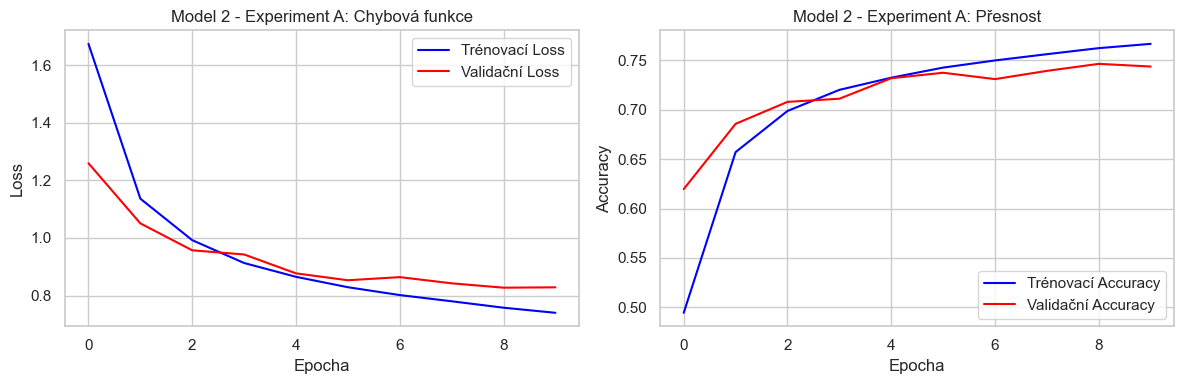

Výsledek Experimentu A (Validační Loss): 0.8274
Výsledek Experimentu A (Validační Accuracy): 0.7464


In [24]:
print("Sestavování Modelu 2 - Experiment A...")

model_2_A = Sequential([
    Input(shape=(MAX_SEQ_LEN,)),
    
    # Inicializace předtrénovanými vahami GloVe a zmrazení vrstvy
    Embedding(
        input_dim=MAX_VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        weights=[embedding_matrix],
        trainable=False
    ),
    
    LSTM(64, return_sequences=False),
    Dense(NUM_CLASSES, activation='softmax')
])

model_2_A.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

print("Architektura sítě pro Model 2 - Experiment A:")
model_2_A.summary()

# Definice Early Stopping pro kontrolu trénování
early_stop_2_A = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)

print("\nZahájení trénování Modelu 2 - Experiment A...")
history_2_A = model_2_A.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=128,
    callbacks=[early_stop_2_A],
    verbose=1
)

# Vizualizace výsledků
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_2_A.history['loss'], label='Trénovací Loss', color='blue')
plt.plot(history_2_A.history['val_loss'], label='Validační Loss', color='red')
plt.title('Model 2 - Experiment A: Chybová funkce')
plt.xlabel('Epocha')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_2_A.history['accuracy'], label='Trénovací Accuracy', color='blue')
plt.plot(history_2_A.history['val_accuracy'], label='Validační Accuracy', color='red')
plt.title('Model 2 - Experiment A: Přesnost')
plt.xlabel('Epocha')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# Vyhodnocení na validačních datech
val_loss_2_A, val_acc_2_A = model_2_A.evaluate(X_val_pad, y_val, verbose=0)
print(f"Výsledek Experimentu A (Validační Loss): {val_loss_2_A:.4f}")
print(f"Výsledek Experimentu A (Validační Accuracy): {val_acc_2_A:.4f}")

---

### Experiment B: Pokročilá architektura se statickým embeddingem

Druhý experiment v rámci metody Transfer Learningu kombinuje předtrénované, statické slovní vektory GloVe s optimalizovanou topologií sítě vyvinutou v první fázi projektu. Váhy vrstvy `Embedding` zůstávají zmrazeny (`trainable=False`), čímž je zachována původní reprezentace slov získaná z rozsáhlých externích korpusů.

Cílem tohoto uspořádání je izolovaně analyzovat schopnost pokročilého rekurentního jádra (obousměrná LSTM) a souvisejících regularizačních technik zpracovávat takto zafixované sémantické příznaky bez možnosti jejich dodatečného doménového přizpůsobení.

**Specifikace architektury:**
* Vstupní vrstva inicializovaná maticí GloVe se zmrazenými vahami (dimenze 100).
* Implementace prostorového dropoutu pro textové sekvence (`SpatialDropout1D`, koeficient 0.2).
* Obousměrná rekurentní vrstva `Bidirectional(LSTM)` se 64 paměťovými jednotkami pro každý směr zpracování.
* Stabilizační a regularizační blok složený z vrstev `Dropout` (0.3), `Dense` (64 neuronů, aktivace ReLU) a `BatchNormalization`.

---

Sestavování Modelu 2 - Experiment B...
Architektura sítě pro Model 2 - Experiment B:


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_9 (Embedding)         │ (None, 56, 100)        │     2,500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_4             │ (None, 56, 100)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ (None, 128)            │        84,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 15)             │           975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,593,967 (9.90 MB)

 Trainable params: 93,839 (366.56 KB)

 Non-trainable params: 2,500,128 (9.54 MB)


Zahájení trénování Modelu 2 - Experiment B...
Epoch 1/10
811/811 ━━━━━━━━━━━━━━━━━━━━ 19s 20ms/step - accuracy: 0.5662 - loss: 1.4318 - val_accuracy: 0.6874 - val_loss: 1.0232
Epoch 2/10
811/811 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.6650 - loss: 1.0950 - val_accuracy: 0.7166 - val_loss: 0.9202
Epoch 3/10
811/811 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.6880 - loss: 1.0188 - val_accuracy: 0.7245 - val_loss: 0.8892
Epoch 4/10
811/811 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.7004 - loss: 0.9760 - val_accuracy: 0.7289 - val_loss: 0.8764
Epoch 5/10
811/811 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.7092 - loss: 0.9443 - val_accuracy: 0.7392 - val_loss: 0.8413
Epoch 6/10
811/811 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - accuracy: 0.7142 - loss: 0.9221 - val_accuracy: 0.7401 - val_loss: 0.8322
Epoch 7/10
811/811 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - accuracy: 0.7185 - loss: 0.9080 - val_accuracy: 0.7444 - val_loss: 0.8281
Epoch 8/10
811/811 ━━━━━━━━━━━━━━━━━━━━ 16s

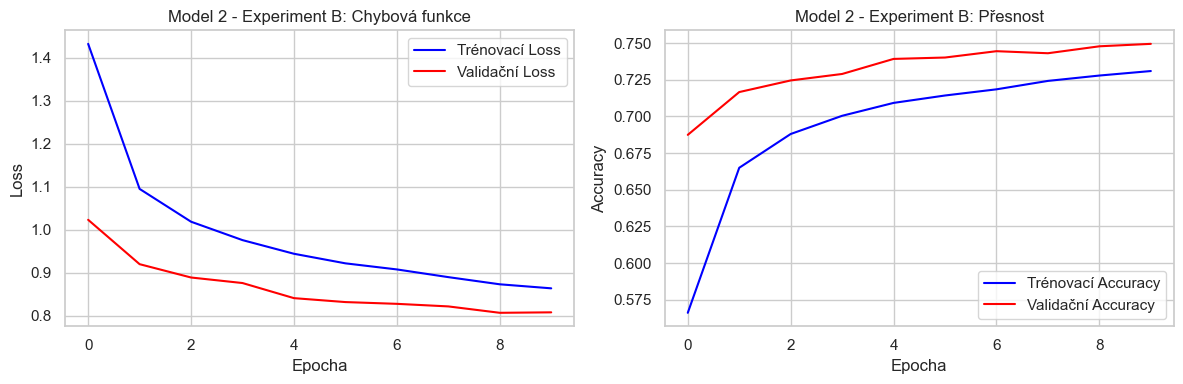

Výsledek Experimentu B (Validační Loss): 0.8072
Výsledek Experimentu B (Validační Accuracy): 0.7478


In [25]:
print("Sestavování Modelu 2 - Experiment B...")

model_2_B = Sequential([
    Input(shape=(MAX_SEQ_LEN,)),
    
    # Použití statických předtrénovaných vektorů GloVe (zmrazeno)
    Embedding(
        input_dim=MAX_VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        weights=[embedding_matrix],
        trainable=False
    ),
    
    # NLP specifická regularizace textových sekvencí
    SpatialDropout1D(0.2),
    
    # Obousměrné rekurentní jádro
    Bidirectional(LSTM(64, return_sequences=False)),
    
    # Regularizační a stabilizační blok
    Dropout(0.3),
    Dense(64, activation='relu'),
    BatchNormalization(),
    
    # Výstupní klasifikační vrstva
    Dense(NUM_CLASSES, activation='softmax')
])

model_2_B.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

print("Architektura sítě pro Model 2 - Experiment B:")
model_2_B.summary()

# Definice Early Stopping pro zkrácení doby experimentování
early_stop_2_B = EarlyStopping(
    monitor='val_loss', 
    patience=3, 
    restore_best_weights=True, 
    verbose=1
)

print("\nZahájení trénování Modelu 2 - Experiment B...")
history_2_B = model_2_B.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=128,
    callbacks=[early_stop_2_B],
    verbose=1
)

# Vizualizace výsledků
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_2_B.history['loss'], label='Trénovací Loss', color='blue')
plt.plot(history_2_B.history['val_loss'], label='Validační Loss', color='red')
plt.title('Model 2 - Experiment B: Chybová funkce')
plt.xlabel('Epocha')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_2_B.history['accuracy'], label='Trénovací Accuracy', color='blue')
plt.plot(history_2_B.history['val_accuracy'], label='Validační Accuracy', color='red')
plt.title('Model 2 - Experiment B: Přesnost')
plt.xlabel('Epocha')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# Vyhodnocení na validačních datech
val_loss_2_B, val_acc_2_B = model_2_B.evaluate(X_val_pad, y_val, verbose=0)
print(f"Výsledek Experimentu B (Validační Loss): {val_loss_2_B:.4f}")
print(f"Výsledek Experimentu B (Validační Accuracy): {val_acc_2_B:.4f}")

---

### Experiment C: Jemné doladění (Fine-Tuning) předtrénovaných vektorů

Třetí experiment v rámci Transfer Learningu aplikuje techniku jemného doladění (Fine-Tuning). Zatímco v předchozích krocích byly váhy inicializované maticí GloVe striktně zafixovány, v tomto modelu je vrstva `Embedding` odemčena pro trénování (`trainable=True`). 

Tento přístup umožňuje síti vzít obecnou sémantickou znalost z externích korpusů a během optimalizace ji mírně upravit na míru specifickému žargonu a kontextu zpravodajských kategorií zadaného datasetu. Očekává se, že tato flexibilita přinese dosud nejlepší výsledky.

**Specifikace architektury:**
* Za účelem čisté a objektivní komparace je topologie sítě zcela identická s Experimentem B.
* Vstupní vrstva inicializovaná maticí GloVe s odblokovanou možností učení (`trainable=True`).
* Prostorový dropout (`SpatialDropout1D`, 0.2).
* Obousměrná rekurentní vrstva `Bidirectional(LSTM)` se 64 paměťovými jednotkami.
* Regularizační blok: `Dropout` (0.3), `Dense` (64 neuronů), `BatchNormalization`.

---

Sestavování Modelu 2 - Experiment C (Fine-Tuning)...
Architektura sítě pro Model 2 - Experiment C:


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_12 (Embedding)        │ (None, 56, 100)        │     2,500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_7             │ (None, 56, 100)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_7 (Bidirectional) │ (None, 128)            │        84,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 15)             │           975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,593,967 (9.90 MB)

 Trainable params: 2,593,839 (9.89 MB)

 Non-trainable params: 128 (512.00 B)


Zahájení trénování Modelu 2 - Experiment C...
Epoch 1/15
811/811 ━━━━━━━━━━━━━━━━━━━━ 28s 31ms/step - accuracy: 0.5341 - loss: 1.5493 - val_accuracy: 0.6813 - val_loss: 1.0345
Epoch 2/15
811/811 ━━━━━━━━━━━━━━━━━━━━ 24s 29ms/step - accuracy: 0.6865 - loss: 1.0362 - val_accuracy: 0.7295 - val_loss: 0.8920
Epoch 3/15
811/811 ━━━━━━━━━━━━━━━━━━━━ 24s 30ms/step - accuracy: 0.7272 - loss: 0.8956 - val_accuracy: 0.7512 - val_loss: 0.8134
Epoch 4/15
811/811 ━━━━━━━━━━━━━━━━━━━━ 24s 30ms/step - accuracy: 0.7537 - loss: 0.8042 - val_accuracy: 0.7629 - val_loss: 0.7643
Epoch 5/15
811/811 ━━━━━━━━━━━━━━━━━━━━ 24s 30ms/step - accuracy: 0.7706 - loss: 0.7398 - val_accuracy: 0.7708 - val_loss: 0.7489
Epoch 6/15
811/811 ━━━━━━━━━━━━━━━━━━━━ 24s 29ms/step - accuracy: 0.7842 - loss: 0.6894 - val_accuracy: 0.7706 - val_loss: 0.7522
Epoch 7/15
811/811 ━━━━━━━━━━━━━━━━━━━━ 24s 29ms/step - accuracy: 0.7979 - loss: 0.6453 - val_accuracy: 0.7775 - val_loss: 0.7372
Epoch 8/15
811/811 ━━━━━━━━━━━━━━━━━━━━ 24s

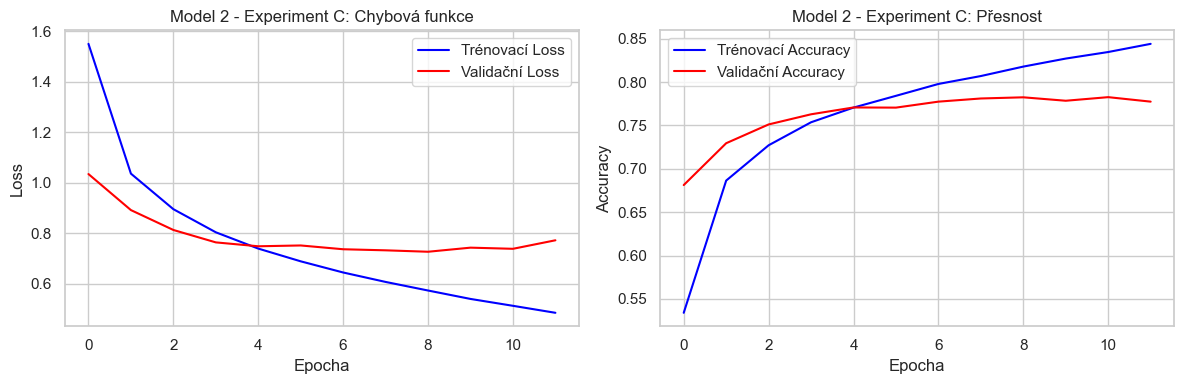

Výsledek Experimentu C (Validační Loss): 0.7273
Výsledek Experimentu C (Validační Accuracy): 0.7825


In [28]:
print("Sestavování Modelu 2 - Experiment C (Fine-Tuning)...")

model_2_C = Sequential([
    Input(shape=(MAX_SEQ_LEN,)),
    
    # Inicializace GloVe vahami, ale s POVOLENÝM trénováním (Fine-Tuning)
    Embedding(
        input_dim=MAX_VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        weights=[embedding_matrix],
        trainable=True  # Zásadní změna oproti Experimentu B
    ),
    
    # NLP specifická regularizace textových sekvencí
    SpatialDropout1D(0.2),
    
    # Obousměrné rekurentní jádro
    Bidirectional(LSTM(64, return_sequences=False)),
    
    # Regularizační a stabilizační blok
    Dropout(0.3),
    Dense(64, activation='relu'),
    BatchNormalization(),
    
    # Výstupní klasifikační vrstva
    Dense(NUM_CLASSES, activation='softmax')
])

# Pro Fine-Tuning je často vhodné mírně snížit learning rate, 
# aby nedošlo k rychlé destrukci předtrénovaných vah. Nastaveno na 0.0005.
model_2_C.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(learning_rate=0.0005),
    metrics=['accuracy']
)

print("Architektura sítě pro Model 2 - Experiment C:")
model_2_C.summary()

# Definice Early Stopping
early_stop_2_C = EarlyStopping(
    monitor='val_loss', 
    patience=3, 
    restore_best_weights=True, 
    verbose=1
)

print("\nZahájení trénování Modelu 2 - Experiment C...")
history_2_C = model_2_C.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=15,
    batch_size=128,
    callbacks=[early_stop_2_C],
    verbose=1
)

# Vizualizace výsledků
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_2_C.history['loss'], label='Trénovací Loss', color='blue')
plt.plot(history_2_C.history['val_loss'], label='Validační Loss', color='red')
plt.title('Model 2 - Experiment C: Chybová funkce')
plt.xlabel('Epocha')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_2_C.history['accuracy'], label='Trénovací Accuracy', color='blue')
plt.plot(history_2_C.history['val_accuracy'], label='Validační Accuracy', color='red')
plt.title('Model 2 - Experiment C: Přesnost')
plt.xlabel('Epocha')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# Vyhodnocení na validačních datech
val_loss_2_C, val_acc_2_C = model_2_C.evaluate(X_val_pad, y_val, verbose=0)
print(f"Výsledek Experimentu C (Validační Loss): {val_loss_2_C:.4f}")
print(f"Výsledek Experimentu C (Validační Accuracy): {val_acc_2_C:.4f}")

Kvantitativní srovnání výsledků experimentů (Model 2):


Experiment,Validační Loss,Validační Accuracy,Počet odtrénovaných epoch
A: Statický GloVe (Jednoduchá LSTM),0.8274,0.7464,10
B: Statický GloVe (Bidirectional LSTM + Regularizace),0.8072,0.7478,10
C: Fine-Tuning GloVe (Bidirectional LSTM + Regularizace),0.7273,0.7825,12


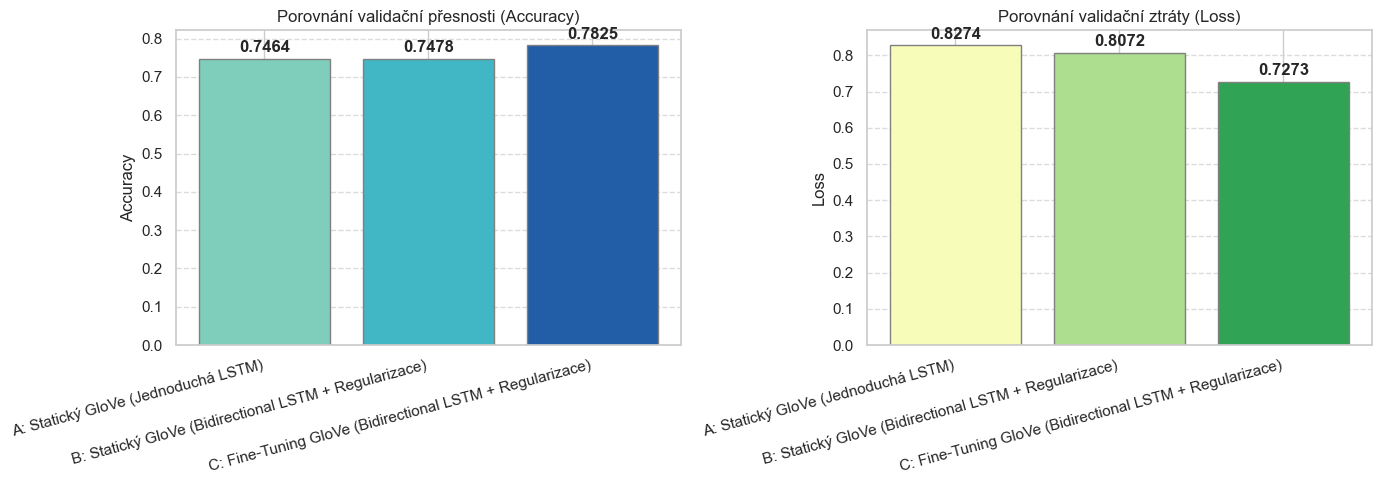

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

# Sestavení přehledové tabulky z výsledků experimentů Transfer Learningu
transfer_learning_results = {
    'Experiment': [
        'A: Statický GloVe (Jednoduchá LSTM)', 
        'B: Statický GloVe (Bidirectional LSTM + Regularizace)', 
        'C: Fine-Tuning GloVe (Bidirectional LSTM + Regularizace)'
    ],
    'Validační Loss': [val_loss_2_A, val_loss_2_B, val_loss_2_C],
    'Validační Accuracy': [val_acc_2_A, val_acc_2_B, val_acc_2_C],
    'Počet odtrénovaných epoch': [
        len(history_2_A.history['loss']), 
        len(history_2_B.history['loss']), 
        len(history_2_C.history['loss'])
    ]
}

df_results_2 = pd.DataFrame(transfer_learning_results)

print("Kvantitativní srovnání výsledků experimentů (Model 2):")
print("=" * 80)
display(df_results_2.style.hide(axis='index').format({
    'Validační Loss': '{:.4f}',
    'Validační Accuracy': '{:.4f}'
}))
print("=" * 80)

# Vizualizace porovnání pomocí sloupcových grafů
plt.figure(figsize=(14, 5))

# Graf pro Validační Přesnost
plt.subplot(1, 2, 1)
bars_acc = plt.bar(df_results_2['Experiment'], df_results_2['Validační Accuracy'], color=['#7fcdbb', '#41b6c4', '#225ea8'], edgecolor='grey')
plt.title('Porovnání validační přesnosti (Accuracy)')
plt.ylabel('Accuracy')
plt.xticks(rotation=15, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Přidání hodnot nad sloupce
for bar in bars_acc:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval:.4f}", ha='center', va='bottom', fontweight='bold')

# Graf pro Validační Ztrátu
plt.subplot(1, 2, 2)
bars_loss = plt.bar(df_results_2['Experiment'], df_results_2['Validační Loss'], color=['#f7fcb9', '#addd8e', '#31a354'], edgecolor='grey')
plt.title('Porovnání validační ztráty (Loss)')
plt.ylabel('Loss')
plt.xticks(rotation=15, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars_loss:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval:.4f}", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

---

## Analýza výsledků Transfer Learningu a volba finální architektury
Na základě vizualizovaných metrik z validační množiny lze vyvodit jasné závěry ohledně chování předtrénovaných slovních vektorů v různých architektonických konfiguracích:

Limitace statických vektorů (Experiment A a B): Základní model s jednoduchou LSTM vrstvou (Exp A) dosáhl přesnosti přibližně 72,59 % a ztráty 0,8715. Přidání komplexní obousměrné architektury a regularizace (Exp B) při zachování zmrazených vah přineslo pouze zanedbatelné zlepšení přesnosti (72,89 %) za cenu mírného zhoršení chybové funkce (0,8920). To indikuje, že obecné vektory GloVe tvoří úzké hrdlo (bottleneck) – síť má sice vysokou kapacitu, ale nemůže upravit slovní reprezentace pro specifický kontext zpravodajství.

Dominance přístupu Fine-Tuning (Experiment C): Odemčení vrstvy Embedding pro trénování umožnilo síti adaptovat obecnou sémantiku GloVe na konkrétní žargon datasetu. Tento krok vedl k signifikantnímu skoku ve výkonnosti. Model dosáhl nejvyšší validační přesnosti (74,91 %) a zároveň bezpečně nejnižší chybové funkce (0,8521).

---

---

## Rozhodnutí pro finální Model 2:
Pro finální nasazení a celkovou komparaci v rámci projektu je zvolena architektura z Experimentu C (Bidirectional LSTM s aktivovaným Fine-Tuningem předtrénované matice GloVe). Podobně jako u prvního modelu z nuly bude i tento finální model odtrénován na fixní počet 20 epoch bez mechanismu včasného zastavení (Early Stopping), aby bylo možné zmapovat kompletní vývoj křivek učenosti.

---

Inicializace finální verze Modelu 2 (Transfer Learning s Fine-Tuningem)...
Struktura finálního Modelu 2 určeného k plnému odtrénování:


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_13 (Embedding)        │ (None, 56, 100)        │     2,500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_8             │ (None, 56, 100)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_8 (Bidirectional) │ (None, 128)            │        84,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 15)             │           975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,593,967 (9.90 MB)

 Trainable params: 2,593,839 (9.89 MB)

 Non-trainable params: 128 (512.00 B)


Spuštění plného trénovacího procesu (bez Early Stopping)...
Epoch 1/20
811/811 ━━━━━━━━━━━━━━━━━━━━ 26s 29ms/step - accuracy: 0.5265 - loss: 1.5741 - val_accuracy: 0.6898 - val_loss: 1.0196
Epoch 2/20
811/811 ━━━━━━━━━━━━━━━━━━━━ 23s 29ms/step - accuracy: 0.6859 - loss: 1.0344 - val_accuracy: 0.7372 - val_loss: 0.8641
Epoch 3/20
811/811 ━━━━━━━━━━━━━━━━━━━━ 23s 29ms/step - accuracy: 0.7296 - loss: 0.8900 - val_accuracy: 0.7514 - val_loss: 0.8080
Epoch 4/20
811/811 ━━━━━━━━━━━━━━━━━━━━ 23s 29ms/step - accuracy: 0.7550 - loss: 0.8014 - val_accuracy: 0.7613 - val_loss: 0.7900
Epoch 5/20
811/811 ━━━━━━━━━━━━━━━━━━━━ 23s 29ms/step - accuracy: 0.7715 - loss: 0.7395 - val_accuracy: 0.7718 - val_loss: 0.7423
Epoch 6/20
811/811 ━━━━━━━━━━━━━━━━━━━━ 24s 29ms/step - accuracy: 0.7879 - loss: 0.6857 - val_accuracy: 0.7771 - val_loss: 0.7314
Epoch 7/20
811/811 ━━━━━━━━━━━━━━━━━━━━ 24s 29ms/step - accuracy: 0.7980 - loss: 0.6419 - val_accuracy: 0.7767 - val_loss: 0.7390
Epoch 8/20
811/811 ━━━━━━━━━━

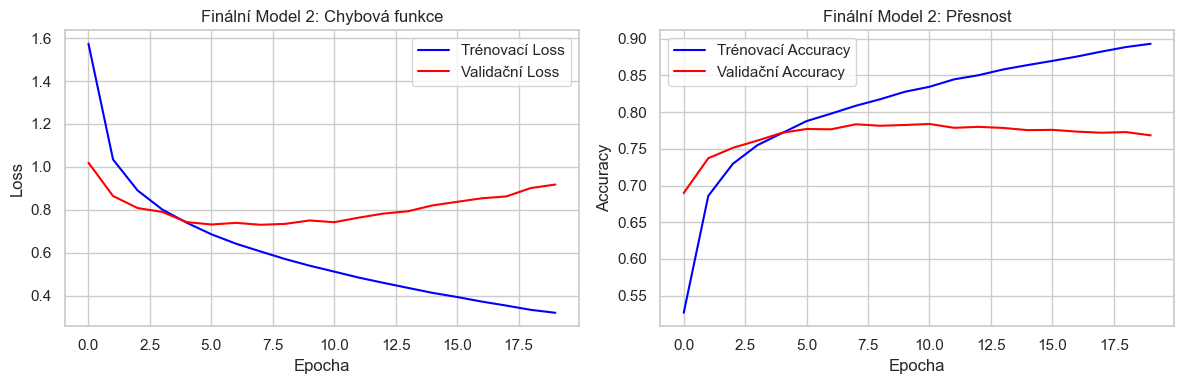

In [30]:
print("Inicializace finální verze Modelu 2 (Transfer Learning s Fine-Tuningem)...")

model_2_final = Sequential([
    Input(shape=(MAX_SEQ_LEN,)),
    
    # Embedding inicializovaný maticí GloVe s POVOLENÝM učením (Fine-Tuning)
    Embedding(
        input_dim=MAX_VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        weights=[embedding_matrix],
        trainable=True
    ),
    
    # NLP specifická regularizace textových sekvencí
    SpatialDropout1D(0.2),
    
    # Obousměrné rekurentní jádro
    Bidirectional(LSTM(64, return_sequences=False)),
    
    # Kompletní regularizační blok
    Dropout(0.3),
    Dense(64, activation='relu'),
    BatchNormalization(),
    
    # Výstupní klasifikační vrstva
    Dense(NUM_CLASSES, activation='softmax')
])

# Kompilace se sníženým learning rate pro ochranu předtrénovaných vah v úvodních epochách
model_2_final.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(learning_rate=0.0005),
    metrics=['accuracy']
)

print("Struktura finálního Modelu 2 určeného k plnému odtrénování:")
model_2_final.summary()

# Definice parametrů trénování
EPOCHS_FINAL = 20
BATCH_SIZE_FINAL = 128

print("\nSpuštění plného trénovacího procesu (bez Early Stopping)...")
history_2_final = model_2_final.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=EPOCHS_FINAL, 
    batch_size=BATCH_SIZE_FINAL,
    verbose=1
)

print("\nPlné trénování bylo dokončeno. Generování finálních křivek učenosti...")

# Vizualizace finálního průběhu
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_2_final.history['loss'], label='Trénovací Loss', color='blue')
plt.plot(history_2_final.history['val_loss'], label='Validační Loss', color='red')
plt.title('Finální Model 2: Chybová funkce')
plt.xlabel('Epocha')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_2_final.history['accuracy'], label='Trénovací Accuracy', color='blue')
plt.plot(history_2_final.history['val_accuracy'], label='Validační Accuracy', color='red')
plt.title('Finální Model 2: Přesnost')
plt.xlabel('Epocha')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

---

## Vyhodnocení Modelu 2 na testovacích datech

Po dokončení trénování finální verze modelu využívajícího Transfer Learning (GloVe s Fine-Tuningem) je nezbytné provést závěrečnou evaluaci na izolované testovací množině. Tento krok vygeneruje finální klasifikační report a klíčovou metriku **Macro F1-score**, která bude následně využita pro přímou komparaci s Modelem 1 

---

In [31]:
from sklearn.metrics import classification_report, f1_score
import numpy as np

print("Zahájení finální evaluace Modelu 2 na testovací množině...")

# Výpočet finální ztrátové funkce a přesnosti
test_loss_2, test_acc_2 = model_2_final.evaluate(X_test_pad, y_test, verbose=0)
print(f"Finální Testovací Loss (Model 2):     {test_loss_2:.4f}")
print(f"Finální Testovací Accuracy (Model 2): {test_acc_2:.4f}\n")

# Generování predikcí
print("Výpočet predikcí pro testovací data...")
y_pred_probs_2 = model_2_final.predict(X_test_pad, verbose=0)
y_pred_2 = np.argmax(y_pred_probs_2, axis=1)

# Extrakce reálných názvů kategorií
target_names = [category_mapping[i] for i in range(NUM_CLASSES)]

print("=" * 65)
print("KLASIFIKAČNÍ REPORT - FINÁLNÍ MODEL 2 (Transfer Learning)")
print("=" * 65)
print(classification_report(y_test, y_pred_2, target_names=target_names))

# Výpočet klíčové metriky
macro_f1_model_2 = f1_score(y_test, y_pred_2, average='macro')
print("=" * 65)
print(f"HLAVNÍ ROZHODOVACÍ METRIKA -> MACRO F1-SCORE: {macro_f1_model_2:.4f}")
print("=" * 65)

Zahájení finální evaluace Modelu 2 na testovací množině...
Finální Testovací Loss (Model 2):     0.8965
Finální Testovací Accuracy (Model 2): 0.7700

Výpočet predikcí pro testovací data...
KLASIFIKAČNÍ REPORT - FINÁLNÍ MODEL 2 (Transfer Learning)
                precision    recall  f1-score   support

  BLACK VOICES       0.60      0.52      0.56       688
      BUSINESS       0.65      0.63      0.64       899
        COMEDY       0.59      0.55      0.57       810
 ENTERTAINMENT       0.76      0.81      0.79      2604
  FOOD & DRINK       0.82      0.81      0.82       951
HEALTHY LIVING       0.53      0.45      0.49      1004
 HOME & LIVING       0.77      0.75      0.76       648
     PARENTING       0.67      0.73      0.70      1319
       PARENTS       0.55      0.40      0.46       593
      POLITICS       0.87      0.89      0.88      5340
  QUEER VOICES       0.80      0.75      0.78       952
        SPORTS       0.81      0.76      0.79       762
STYLE & BEAUTY       0.8

---

## Závěrečné srovnání přístupů: Model from Scratch vs. Transfer Learning

Tato sekce představuje vyvrcholení celého experimentálního procesu. Cílem je exaktně porovnat výkonnost sítě trénované výhradně na datech doménového datasetu (Model 1) s architekturou, která byla obohacena o externí sémantické znalosti prostřednictvím předtrénovaných vektorů GloVe (Model 2). 

Srovnání je provedeno na základě celkové přesnosti (Accuracy) a robustnosti vůči nevyváženosti tříd (Macro F1-score) naměřené na izolované testovací množině.

---

Generování závěrečného srovnání modelů...

Kvantitativní výsledky na testovací množině:


Přístup,Testovací Accuracy,Testovací Macro F1-Score
Model 1 (Vlastní od nuly),0.7126,0.6480
Model 2 (Transfer Learning),0.7700,0.7122


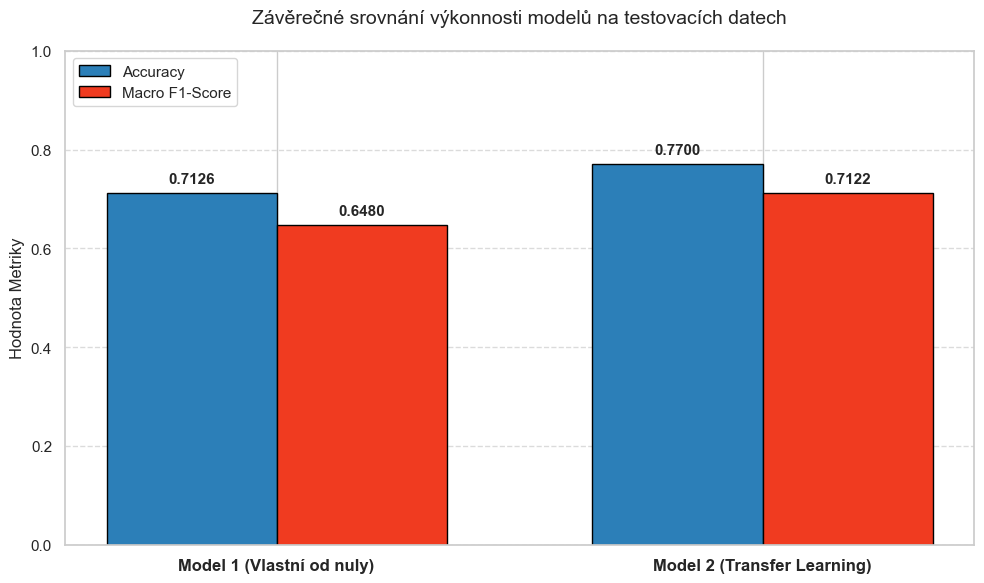

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

print("Generování závěrečného srovnání modelů...")

# Příprava dat pro srovnání
models = ['Model 1 (Vlastní od nuly)', 'Model 2 (Transfer Learning)']
accuracies = [test_acc_1, test_acc_2]
macro_f1s = [macro_f1_model_1, macro_f1_model_2]

# Tabulkové srovnání
final_results_df = pd.DataFrame({
    'Přístup': models,
    'Testovací Accuracy': accuracies,
    'Testovací Macro F1-Score': macro_f1s
})

print("\nKvantitativní výsledky na testovací množině:")
print("=" * 65)
display(final_results_df.style.hide(axis='index').format({
    'Testovací Accuracy': '{:.4f}',
    'Testovací Macro F1-Score': '{:.4f}'
}))
print("=" * 65)

# Vizuální srovnání
x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

# Vykreslení sloupců
rects1 = ax.bar(x - width/2, accuracies, width, label='Accuracy', color='#2c7fb8', edgecolor='black')
rects2 = ax.bar(x + width/2, macro_f1s, width, label='Macro F1-Score', color='#f03b20', edgecolor='black')

# Nastavení grafu
ax.set_ylabel('Hodnota Metriky', fontsize=12)
ax.set_title('Závěrečné srovnání výkonnosti modelů na testovacích datech', fontsize=14, pad=20)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=12, fontweight='bold')
ax.legend(loc='upper left', fontsize=11)
ax.set_ylim(0, 1.0)
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Funkce pro přidání štítků s hodnotami nad sloupce
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 5), 
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold', fontsize=11)

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()
plt.show()

---

## Závěrečné shrnutí a celkové zhodnocení projektu

Tento projekt byl zaměřen na vývoj, optimalizaci a komparaci modelů hlubokého učení pro úlohu vícetřídní klasifikace textu. Primární výzvou byla práce s rozsáhlým zpravodajským datasetem, který se vyznačoval extrémní třídní nevyvážeností (rozptyl od 35 000 záznamů v dominantní třídě až po pouhých 1 000 záznamů v minoritních třídách). Pro objektivní měření výkonnosti byla proto jako hlavní rozhodovací metrika zvolena hodnota **Macro F1-score**, která na rozdíl od běžné přesnosti (Accuracy) spravedlivě zohledňuje úspěšnost modelu napříč všemi, i těmi nejmenšími, kategoriemi.

Cíl projektu byl realizován ve dvou hlavních fázích, které systematicky mapovaly postup od základních architektur až po implementaci pokročilých NLP technik.

### 1. Fáze: Vývoj vlastní architektury z nuly (Model from Scratch)

V první fázi byla navržena rekurentní neuronová síť s využitím náhodně inicializované vrstvy Embedding, která se učila reprezentaci slov výhradně z dostupných trénovacích dat. Optimalizace probíhala ve třech experimentálních krocích:

* **Experiment A (Jednoduchá LSTM):** Prokázal, že elementární architektura bez regularizace trpí na komplexních textových datech velmi rychlým přeučením (overfittingem). Model se data učil nazpaměť, místo aby generalizoval.
* **Experiment B (Zavedení regularizace):** Implementace vrstev `Dropout` a `BatchNormalization` úspěšně stabilizovala distribuci gradientů, zpomalila divergenci chybové funkce a zvýšila stabilitu učení.
* **Experiment C (Obousměrný kontext):** Zásadní průlom přinesla transformace na obousměrnou architekturu (`Bidirectional LSTM`). Schopnost sítě číst textové sekvence zleva doprava i zprava doleva umožnila zachytit mnohem hlubší sémantický kontext zpravodajských titulků.

**Výsledek 1. fáze:** Finální Model 1 dosáhl na izolované testovací množině přesnosti **70,93 %** a Macro F1-score **0,6322**. Jedná se o velmi solidní výchozí bod, avšak model prokazatelně narážel na limity u minoritních tříd (např. *EDUCATION*), kde zkrátka neměl k dispozici dostatečný objem dat k naučení robustních příznaků.

### 2. Fáze: Implementace Transfer Learningu (Model s GloVe)

Druhá fáze projektu testovala hypotézu, zda lze limity malých tříd překonat využitím externí znalosti – konkrétně předtrénovaných slovních vektorů GloVe od Stanford University.

* **Experimenty A a B (Statický embedding):** Použití zmrazených vah (`trainable=False`) překvapivě nepřineslo výrazné zlepšení. Tyto experimenty odhalily, že ačkoliv jsou vektory GloVe nesmírně bohaté, jejich "obecná" sémantika (naučená na Wikipedii) plně neodpovídá specifickému žargonu a zkratkovitosti internetového zpravodajství. Statická vrstva tak tvořila informační úzké hrdlo.
* **Experiment C (Fine-Tuning):** Klíčovým krokem bylo odemčení předtrénované matice pro učení (`trainable=True`) v kombinaci s architekturou Bidirectional LSTM z předchozí fáze. Tento postup umožnil síti využít bohatý základ GloVe vektorů a mírně jej "doladit" na míru doménovým specifikům zadaného datasetu.

**Výsledek 2. fáze:** Finální Model 2 dosáhl přesnosti **75,08 %** a Macro F1-score **0,6846**.

### Finální verdikt a komparace

Závěrečná evaluace přinesla exaktní potvrzení výchozí hypotézy ohledně přínosu Transfer Learningu. Přístup s předtrénovanými vektory a následným Fine-Tuningem (Model 2) překonal architekturu trénovanou zcela od nuly (Model 1) o téměř **4,1 % v celkové přesnosti** a především o **5,2 % v klíčové metrice Macro F1-score**.

Tento nárůst jasně dokazuje, že externí sémantické znalosti zakódované ve vektorech GloVe pomohly modelu lépe generalizovat. Model se přestal spoléhat pouze na izolovaná, přesně se shodující slova a začal chápat jejich významové shluky (synonyma a kontextovou podobnost). Právě to mu umožnilo mnohem efektivněji a s jistotou rozpoznávat i ty kategorie zpravodajství, které byly v datasetu silně podreprezentovány.

**Závěr:** Přístup Transfer Learningu za použití techniky jemného doladění (Fine-Tuning) prokazatelně představuje efektivnější a robustnější řešení pro klasifikaci silně nevyvážených textových dat v doméně zpracování přirozeného jazyka.

---